#GETTING THE DATASET
**ONLY RUN ONCE**

In [ ]:
!pip install cdsapi xarray netCDF4 matplotlib seaborn

In [ ]:
import os

with open('/root/.cdsapirc', 'w') as f:
    f.write("""url: https://cds.climate.copernicus.eu/api
key: 536983a1-c3b0-4765-86f6-820e46ba8da8
""")

We want to start simple so we will first focus on short term forecasting. Since the ERA5 dataset is a huge dataset with 20TB+ data, we would want to work with a subset of data.

Hence we will:


*   Constraint ourself to a subset of region (North India in our case) instead of global predictions.
*   We will initially only predict/forcast temperature values.
*   We will only use a subset of variables for now, which would be Temperature, Wind Speed, Precipitation, Surface Pressure, Humidity and Solar Radiation.
*   We will limit the time of observation so we don't end up with huge dataset.





###Variables:
We chose the following variables:

1. 2m Temperature (t2m) : Air temperature at 2 meters above the surface (in Kelvin)

2. Surface Pressure (sp) : Atmospheric pressure at the Earth’s surface (in Pascals)

3. 10m U-component of Wind (u10) :  East–west wind component at 10 meters height

4. 10m V-component of Wind (v10) : North–south wind component at 10 meters height

5. Surface Solar Radiation Downwards : Amount of solar energy reaching the surface (J/m²)

6. Total Precipitation (tp) : Total accumulated precipitation (rain/snow) over a time interval (meters)

7. 2m Dew Point Temperature (d2m) : Temperature at which air becomes saturated (100% humidity) at 2 meters. It tells you how much moisture is in the air.


###Latitude and Longitude:

For North India, We choose **Latitude range** from 37 to 25 and for **Longitude Range** we choose 70 to 85.


###Time Stamps:

The dataset spans from April 1, 2023 to September 30, 2023, with a temporal resolution of 3 hours (8 observations per day), resulting in a total of 1464 time steps.


In [ ]:
import cdsapi

c = cdsapi.Client()

years = ['2021', '2022', '2023']
months = ['01','02','03','04','05','06','07','08','09','10','11','12']

# chunk months into groups of 4
month_chunks = [months[i:i+4] for i in range(0, len(months), 4)]

for year in years:
    for chunk in month_chunks:
        file_path = f"era5_{year}_{chunk[0]}_{chunk[-1]}.nc"

        c.retrieve(
            'reanalysis-era5-single-levels',
            {
                'product_type': 'reanalysis',
                'variable': [
                    'total_column_water_vapour',
                    'total_cloud_cover',
                    'vertical_integral_of_divergence_of_moisture_flux',
                    '2m_temperature',
                    '10m_u_component_of_wind',
                    '10m_v_component_of_wind',
                    'total_precipitation',
                    '2m_dewpoint_temperature'
                ],
                'year': year,
                'month': chunk,  # <-- multiple months here
                'day': [f"{i:02d}" for i in range(1, 32)],
                'time': [f"{i:02d}:00" for i in range(0, 24, 3)],
                'area': [37, 70, 25, 85],
                'format': 'netcdf',
            },
            file_path
        )

        print(f"Downloaded: {file_path}")

2026-04-26 10:46:13,602 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

7e44bb4a2f309ffc8160d677babb9b2c.zip:   0%|          | 0.00/39.1M [00:00<?, ?B/s]

Downloaded: era5_2021_01_04.nc


2026-04-26 10:50:38,241 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

2e291f316584c0a86934542e3f25b6a8.zip:   0%|          | 0.00/42.6M [00:00<?, ?B/s]

...

fc62ac5ae3a45a0633975c64d27bfbed.zip:   0%|          | 0.00/42.5M [00:00<?, ?B/s]

Downloaded: era5_2023_05_08.nc


2026-04-26 12:01:44,978 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

c4f4bfa62d169b297e1d379713dfe8a1.zip:   0%|          | 0.00/39.9M [00:00<?, ?B/s]

Downloaded: era5_2023_09_12.nc


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_dir = "/content/drive/MyDrive/era5_new_data"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
import shutil
import glob

files = glob.glob("/content/*.nc")

for f in files:
    shutil.move(f, save_dir)

print("All files moved to Drive")

All files moved to Drive


In [ ]:
import shutil
shutil.rmtree("/content/drive/MyDrive/era5_unzipped", ignore_errors=True)

In [ ]:
import zipfile
import glob
import os

zip_dir = "/content/drive/MyDrive/era5_new_data"
extract_dir = "/content/drive/MyDrive/era5_unzipped"

os.makedirs(extract_dir, exist_ok=True)

zip_files = sorted(glob.glob(f"{zip_dir}/*.nc"))  # your zip files

for f in zip_files:
    # create unique folder name per file
    name = os.path.basename(f).replace(".nc", "")
    out_path = os.path.join(extract_dir, name)
    os.makedirs(out_path, exist_ok=True)

    with zipfile.ZipFile(f, 'r') as zip_ref:
        zip_ref.extractall(out_path)

    print(f"Extracted: {name}")

Extracted: era5_2021_01_04
Extracted: era5_2021_05_08
Extracted: era5_2021_09_12
Extracted: era5_2022_01_04
Extracted: era5_2022_05_08
Extracted: era5_2022_09_12
Extracted: era5_2023_01_04
Extracted: era5_2023_05_08
Extracted: era5_2023_09_12


9 9


Saving the downloaded dataset to Drive

RUN FROM HERE

Getting the data from Drive and merging data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob

inst_files = sorted(glob.glob("/content/drive/MyDrive/era5_unzipped/*/*instant*.nc"))
acc_files  = sorted(glob.glob("/content/drive/MyDrive/era5_unzipped/*/*accum*.nc"))

print(len(inst_files), len(acc_files))

9 9


In [ ]:
import xarray as xr

inst = xr.open_mfdataset(
    inst_files,
    combine="nested",
    concat_dim="valid_time",
    engine="h5netcdf"
)

acc = xr.open_mfdataset(
    acc_files,
    combine="nested",
    concat_dim="valid_time",
    engine="h5netcdf"
)

In [ ]:
ds = xr.merge([inst, acc])

print(ds)

<xarray.Dataset> Size: 838MB
Dimensions:     (valid_time: 8760, latitude: 49, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2023-12-31T21...
  * latitude    (latitude) float64 392B 37.0 36.75 36.5 ... 25.5 25.25 25.0
  * longitude   (longitude) float64 488B 70.0 70.25 70.5 ... 84.5 84.75 85.0
    number      int64 8B 0
    expver      (valid_time) <U4 140kB dask.array<chunksize=(960,), meta=np.ndarray>
Data variables:
    tcwv        (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    tcc         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    vimdf       (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 105MB 

/tmp/ipykernel_13191/2465305730.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([inst, acc])
/tmp/ipykernel_13191/2465305730.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([inst, acc])


#PREPROCESSING AND EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
ds

<xarray.Dataset> Size: 838MB
Dimensions:     (valid_time: 8760, latitude: 49, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2021-01-01 ... 2023-12-31T21...
  * latitude    (latitude) float64 392B 37.0 36.75 36.5 ... 25.5 25.25 25.0
  * longitude   (longitude) float64 488B 70.0 70.25 70.5 ... 84.5 84.75 85.0
    number      int64 8B 0
    expver      (valid_time) <U4 140kB dask.array<chunksize=(960,), meta=np.ndarray>
Data variables:
    tcwv        (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    tcc         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    vimdf       (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-26T10:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
print(ds.dims)
print(ds.data_vars)

FrozenMappingWarningOnValuesAccess({'valid_time': 8760, 'latitude': 49, 'longitude': 61})
Data variables:
    tcwv     (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    tcc      (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    vimdf    (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    t2m      (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    u10      (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    v10      (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    d2m      (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61), meta=np.ndarray>
    tp       (valid_time, latitude, longitude) float32 105MB dask.array<chunksize=(960, 49, 61),

## Converting data to CSV

In [ ]:
df = ds.to_dataframe().reset_index()

In [ ]:
df

,valid_time,latitude,longitude,tcwv,tcc,vimdf,t2m,u10,v10,d2m,number,expver,tp
0,2021-01-01 00:00:00,37.0,70.00,0.956319,0.000000,0.000002,262.620453,-2.478943,-0.540939,252.871841,0,0001,0.0
1,2021-01-01 00:00:00,37.0,70.25,0.637960,0.000000,0.000019,255.399750,-2.209412,0.684647,249.071060,0,0001,0.0
2,2021-01-01 00:00:00,37.0,70.50,0.516866,0.000000,0.000016,251.847015,-2.393982,1.043045,245.115982,0,0001,0.0
3,2021-01-01 00:00:00,37.0,70.75,0.458272,0.000000,0.000007,250.235687,-2.360779,1.081131,240.674576,0,0001,0.0
4,2021-01-01 00:00:00,37.0,71.00,0.387960,0.000000,-0.000001,251.159515,-1.930115,-0.291916,239.434341,0,0001,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26183635,2023-12-31 21:00:00,25.0,84.00,13.103206,1.000000,-0.000075,284.154083,0.936447,0.380997,283.361389,0,0001,0.0
26183636,2023-12-31 21:00:00,25.0,84.25,12.800471,0.541779,-0.000042,284.308380,1.171799,0.165176,283.521545,0,0001,0.0
26183637,2023-12-31 21:00:00,25.0,84.50,12.509456,0.010834,-0.000062,284.357208,1.121017,0.247208,283.441467,0,0001,0.0
26183638,2023-12-31 21:00:00,25.0,84.75,11.982112,0.031189,-0.000069,284.240021,1.076096,0.064590,283.326233,0,0001,0.0


# The dataset consists of meteorological variables such as temperature, pressure, wind components, solar radiation, and precipitation. Temperature and dew point are recorded in Kelvin, pressure in Pascals, wind in m/s, and precipitation in meters. Metadata columns such as ensemble number and experiment version needs to be  removed as they do not contribute to the analysis.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26183640 entries, 0 to 26183639
Data columns (total 13 columns):
 #   Column      Dtype         
---  ------      -----         
 0   valid_time  datetime64[ns]
 1   latitude    float64       
 2   longitude   float64       
 3   tcwv        float32       
 4   tcc         float32       
 5   vimdf       float32       
 6   t2m         float32       
 7   u10         float32       
 8   v10         float32       
 9   d2m         float32       
 10  number      int64         
 11  expver      object        
 12  tp          float32       
dtypes: datetime64[ns](1), float32(8), float64(2), int64(1), object(1)
memory usage: 1.8+ GB


,valid_time,latitude,longitude,tcwv,tcc,vimdf,t2m,u10,v10,d2m,number,tp
count,26183640,2.618364e+07,2.618364e+07,2.618364e+07,2.618364e+07,2.618364e+07,2.618364e+07,2.618364e+07,2.618364e+07,2.618364e+07,26183640.0,2.618364e+07
mean,2022-07-02 10:30:00.000001280,3.100000e+01,7.750000e+01,1.812363e+01,3.922807e-01,-4.240937e-06,2.850038e+02,3.537264e-01,1.271125e-01,2.765485e+02,0.0,8.507043e-05
min,2021-01-01 00:00:00,2.500000e+01,7.000000e+01,4.163708e-02,0.000000e+00,-2.749405e-02,2.244032e+02,-1.643097e+01,-1.581468e+01,2.143708e+02,0.0,0.000000e+00
25%,2021-10-01 17:15:00,2.800000e+01,7.375000e+01,3.647514e+00,8.544922e-04,-5.052984e-05,2.714453e+02,-7.388306e-01,-9.187775e-01,2.639008e+02,0.0,0.000000e+00
50%,2022-07-02 10:30:00,3.100000e+01,7.750000e+01,1.165482e+01,2.557983e-01,4.503876e-06,2.875451e+02,2.053833e-01,3.765869e-02,2.804947e+02,0.0,0.000000e+00
75%,2023-04-02 03:45:00,3.400000e+01,8.125000e+01,2.492201e+01,8.107300e-01,6.288290e-05,3.002170e+02,1.343216e+00,1.072418e+00,2.897690e+02,0.0,8.583069e-06
max,2023-12-31 21:00:00,3.700000e+01,8.500000e+01,9.126601e+01,1.000000e+00,5.253609e-03,3.225132e+02,1.766435e+01,3.163408e+01,3.052803e+02,0.0,6.224060e-02
std,NaN,3.535534e+00,4.401704e+00,1.796060e+01,3.883427e-01,2.047398e-04,4.448491e+01,1.863072e+00,1.634189e+00,4.225170e+01,0.0,4.222282e-04


In [ ]:
df["t2m"] = df["t2m"] - 273.15
df["d2m"] = df["d2m"] - 273.15
df["tp"] = df["tp"] * 1000  # meters → mm

#### Finding wind velocity by combining it's 2 normal components: using (v ** 2 + u ** 2) ** 0.5

In [ ]:
df["wind_speed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)
df["wind_dir"] = np.arctan2(df["v10"], df["u10"])

In [ ]:
df = df.drop(columns=['u10', 'v10']) ## Removing these columns bcoz we have velocity as our feature variable

## Making valid_time daterime and converting tp to hourly tp as now it's representing total accumulated rain till that timestamp

In [ ]:
import pandas as pd
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by=['latitude','longitude','valid_time'])
df['tp_hourly'] = df.groupby(['latitude','longitude'])['tp'].diff()
df['tp_hourly'] = df['tp_hourly'].clip(lower=0)

In [ ]:
df['tp_hourly'] = df['tp_hourly'].fillna(0)

In [ ]:
df = df.drop(columns=['tp'])

In [ ]:
df.head()

,valid_time,latitude,longitude,tcwv,tcc,vimdf,t2m,d2m,number,expver,wind_speed,wind_dir,tp_hourly
2928,2021-01-01 00:00:00,25.0,70.0,9.202413,0.0,-0.000006,9.085687,1.057764,0,0001,4.662417,-1.733938,0.0
5917,2021-01-01 03:00:00,25.0,70.0,8.913366,0.0,0.000056,9.260950,1.194452,0,0001,4.361473,-1.786166,0.0
8906,2021-01-01 06:00:00,25.0,70.0,8.724771,0.0,-0.000003,18.004236,0.684167,0,0001,5.236057,-1.776868,0.0
11895,2021-01-01 09:00:00,25.0,70.0,9.163505,0.0,0.000084,21.844720,-0.396704,0,0001,5.327116,-1.500108,0.0
14884,2021-01-01 12:00:00,25.0,70.0,8.124203,0.0,0.000046,21.448022,-2.535254,0,0001,5.366546,-1.423064,0.0


### Plots:

In [ ]:
df = df.drop(columns=['number', 'expver'])

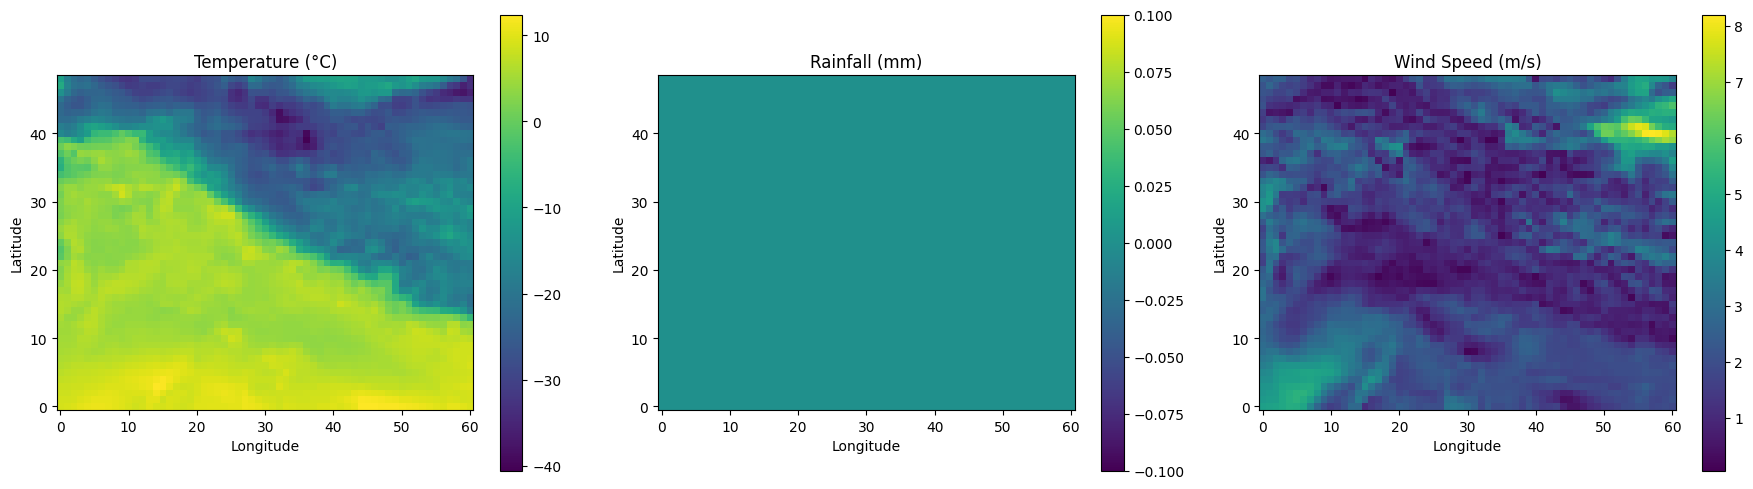

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

df_t = df[df['valid_time'] == df['valid_time'].iloc[0]] ## Viewing for a specific time

temp = df_t.pivot(index='latitude', columns='longitude', values='t2m')
rain = df_t.pivot(index='latitude', columns='longitude', values='tp_hourly')
wind = df_t.pivot(index='latitude', columns='longitude', values='wind_speed')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].imshow(temp, origin='lower')
axes[0].set_title("Temperature (°C)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(rain, origin='lower')
axes[1].set_title("Rainfall (mm)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(wind, origin='lower')
axes[2].set_title("Wind Speed (m/s)")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

##### From these plots:
The temperature distribution exhibits a clear spatial gradient, with warmer regions concentrated in the southern part and cooler regions in the northern part, indicating strong spatial dependency influenced by geographic factors.

The rainfall distribution is largely sparse, with most regions showing negligible precipitation at the selected timestep. This highlights the intermittent and localized nature of rainfall events, making prediction more challenging.

Wind speed exhibits complex and irregular spatial patterns, indicating localized atmospheric dynamics and variability, which are more difficult to model compared to temperature.

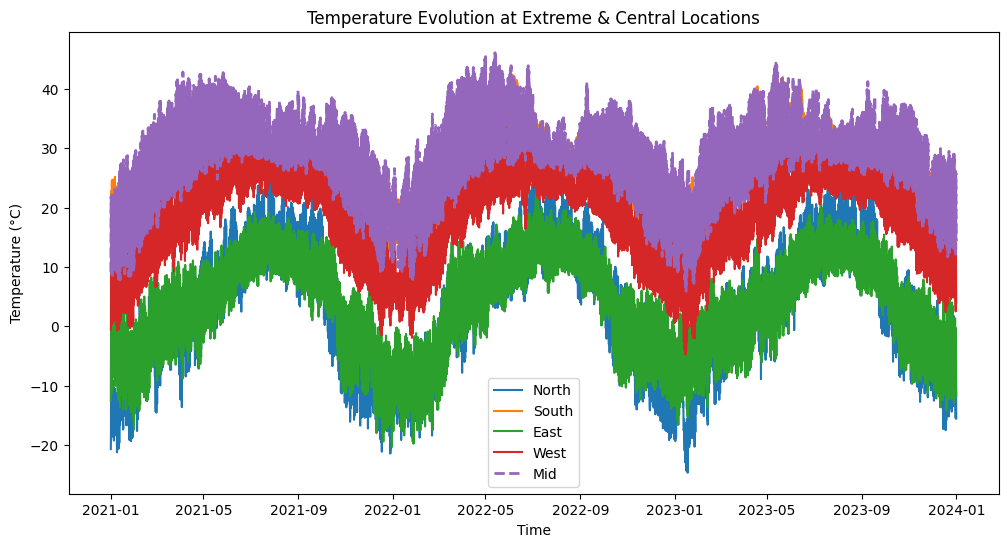

In [ ]:
north = df['latitude'].max()
south = df['latitude'].min()
east = df['longitude'].max()
west = df['longitude'].min()

mid_lat = df['latitude'].mean()
mid_lon = df['longitude'].mean()

mid_point = df.iloc[((df['latitude'] - mid_lat)**2 + (df['longitude'] - mid_lon)**2).idxmin()]

mid_lat_actual = mid_point['latitude']
mid_lon_actual = mid_point['longitude']

df_north = df[df['latitude'] == north].groupby('valid_time').mean(numeric_only=True).reset_index()
df_south = df[df['latitude'] == south].groupby('valid_time').mean(numeric_only=True).reset_index()
df_east  = df[df['longitude'] == east].groupby('valid_time').mean(numeric_only=True).reset_index()
df_west  = df[df['longitude'] == west].groupby('valid_time').mean(numeric_only=True).reset_index()

df_mid = df[(df['latitude'] == mid_lat_actual) & (df['longitude'] == mid_lon_actual)]

plt.figure(figsize=(12,6))

plt.plot(df_north['valid_time'], df_north['t2m'], label='North')
plt.plot(df_south['valid_time'], df_south['t2m'], label='South')
plt.plot(df_east['valid_time'], df_east['t2m'], label='East')
plt.plot(df_west['valid_time'], df_west['t2m'], label='West')
plt.plot(df_mid['valid_time'], df_mid['t2m'], label='Mid', linewidth=2, linestyle='--')

plt.title("Temperature Evolution at Extreme & Central Locations")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

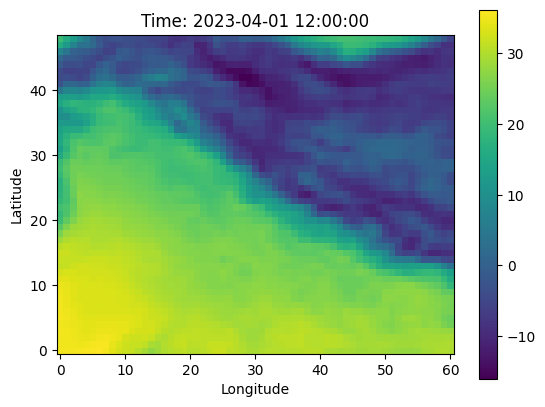

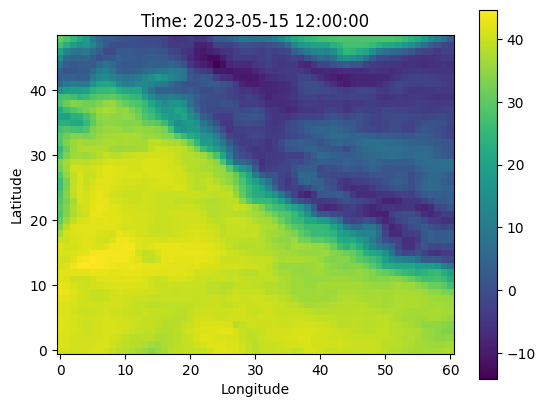

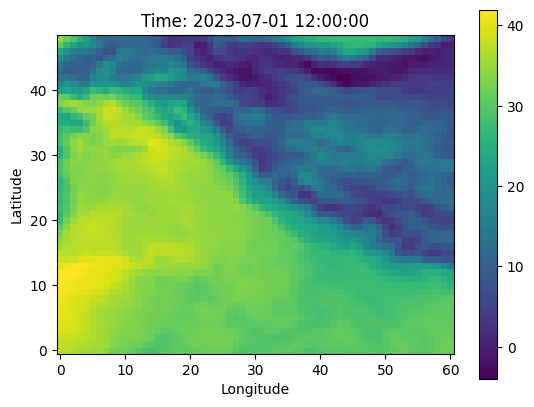

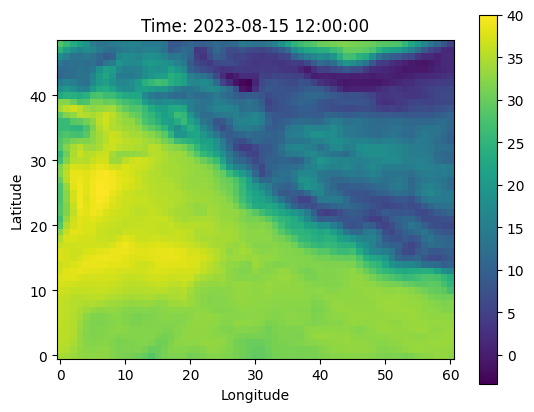

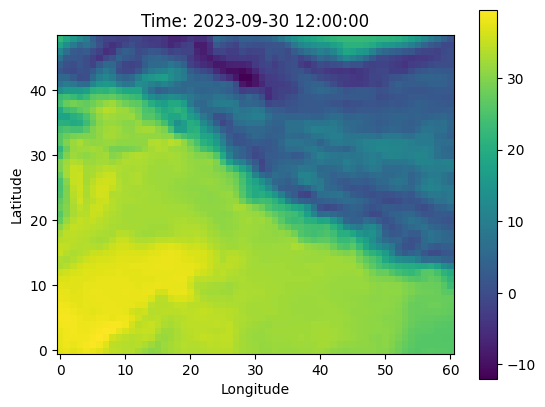

In [ ]:
selected_times = [
    '2023-04-01 12:00:00',
    '2023-05-15 12:00:00',
    '2023-07-01 12:00:00',
    '2023-08-15 12:00:00',
    '2023-09-30 12:00:00'
]

for t in selected_times:
    df_t = df[df['valid_time'] == t]

    pivot = df_t.pivot(index='latitude', columns='longitude', values='t2m')

    plt.imshow(pivot, origin='lower')
    plt.title(f"Time: {t}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar()
    plt.show()

### These plots shows us how the temperature changes with time

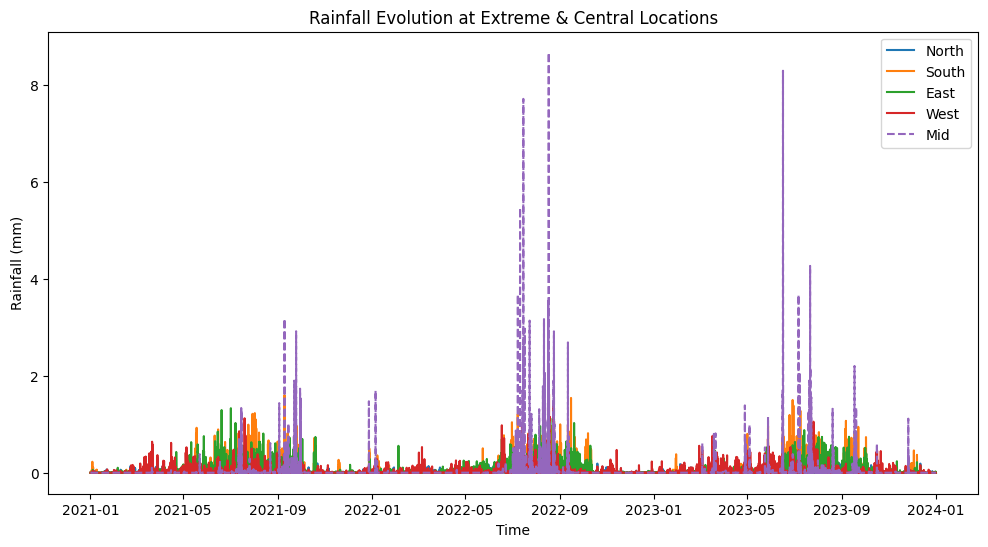

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_north['valid_time'], df_north['tp_hourly'], label='North')
plt.plot(df_south['valid_time'], df_south['tp_hourly'], label='South')
plt.plot(df_east['valid_time'], df_east['tp_hourly'], label='East')
plt.plot(df_west['valid_time'], df_west['tp_hourly'], label='West')
plt.plot(df_mid['valid_time'], df_mid['tp_hourly'], label='Mid', linestyle='--')

plt.title("Rainfall Evolution at Extreme & Central Locations")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()

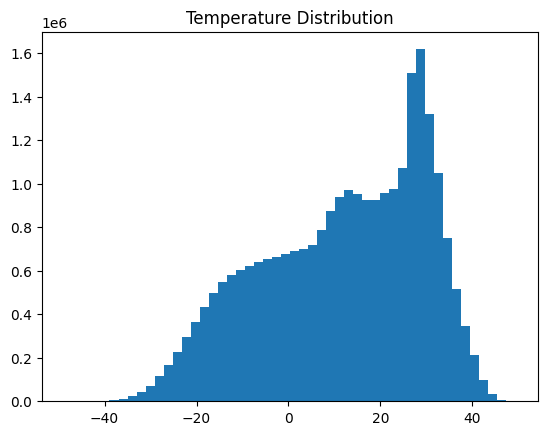

In [ ]:
plt.hist(df['t2m'], bins=50)
plt.title("Temperature Distribution")
plt.show()

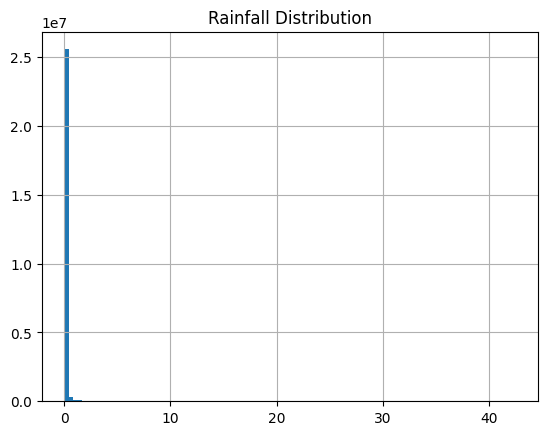

In [ ]:
df["tp_hourly"].hist(bins=100)
plt.title("Rainfall Distribution")
plt.show()

In [ ]:
df["rain"] = (df["tp_hourly"] > 0).astype(int)
df["rain"].value_counts(normalize=True)

,proportion
rain,
0,0.788336
1,0.211664


In [ ]:
df = df.drop(columns=['rain'])

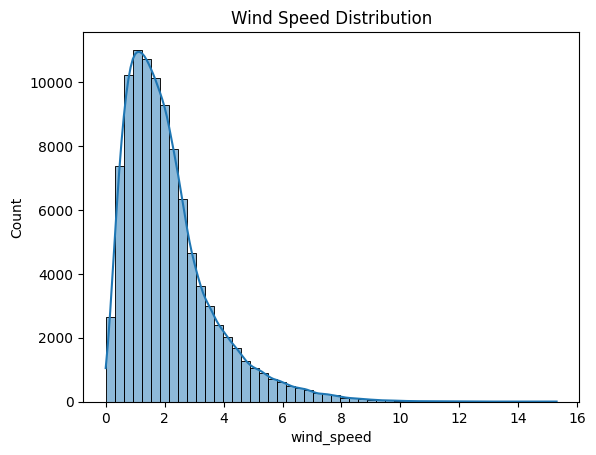

In [ ]:
sns.histplot(sample_df["wind_speed"], bins=50, kde=True)
plt.title("Wind Speed Distribution")
plt.show()

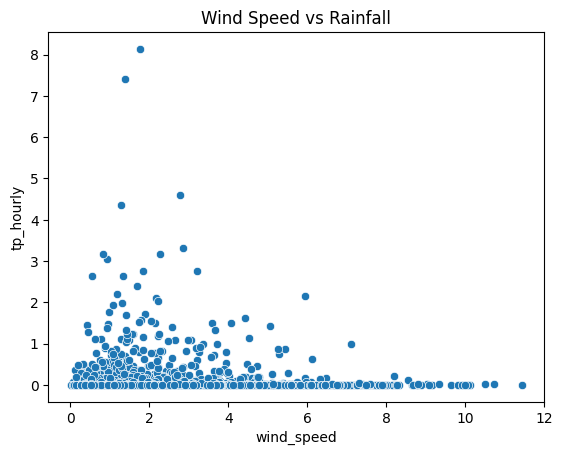

In [ ]:
sns.scatterplot(x="wind_speed", y="tp_hourly", data=sample_df.sample(5000))
plt.title("Wind Speed vs Rainfall")
plt.show()

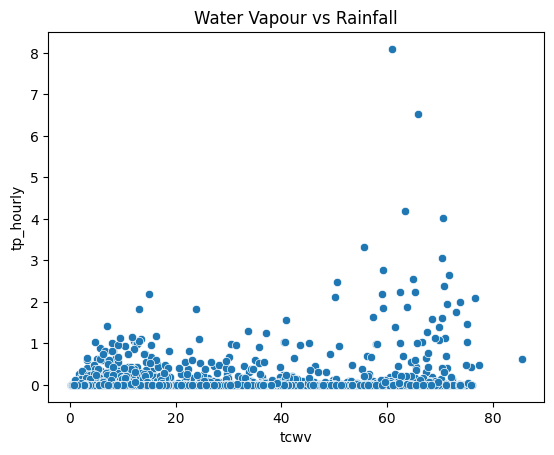

In [ ]:
sns.scatterplot(x="tcwv", y="tp_hourly", data=sample_df.sample(5000))
plt.title("Water Vapour vs Rainfall")
plt.show()

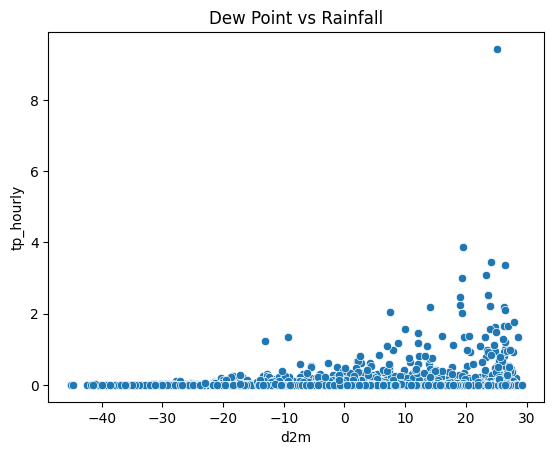

In [ ]:
sns.scatterplot(x="d2m", y="tp_hourly", data=sample_df.sample(5000))
plt.title("Dew Point vs Rainfall")
plt.show()

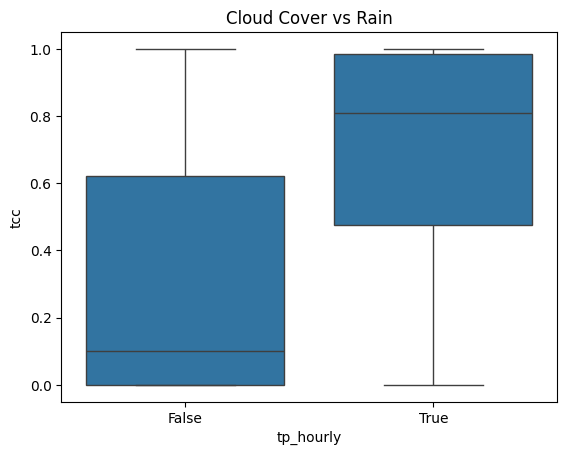

In [ ]:
sns.boxplot(x=(sample_df["tp_hourly"] > 0), y="tcc", data=sample_df)
plt.title("Cloud Cover vs Rain")
plt.show()

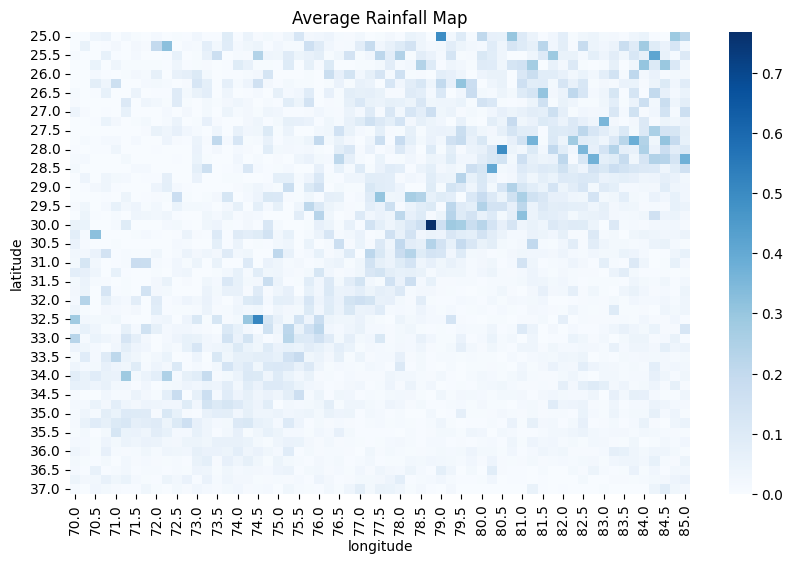

In [ ]:
pivot = sample_df.pivot_table(
    values="tp_hourly",
    index="latitude",
    columns="longitude",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Average Rainfall Map")
plt.show()

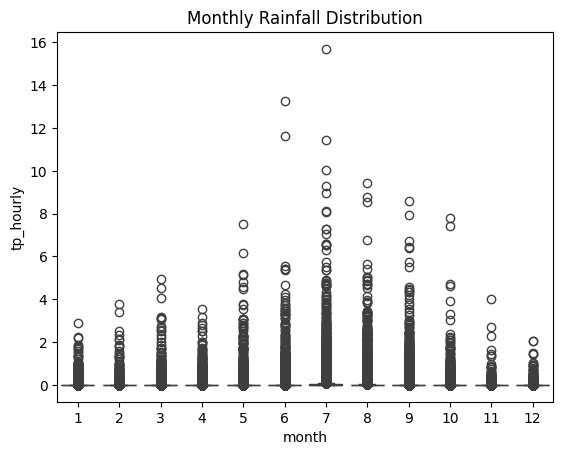

In [ ]:
sample_df["valid_time"] = pd.to_datetime(sample_df["valid_time"])
sample_df["month"] = sample_df["valid_time"].dt.month

sns.boxplot(x="month", y="tp_hourly", data=sample_df)
plt.title("Monthly Rainfall Distribution")
plt.show()

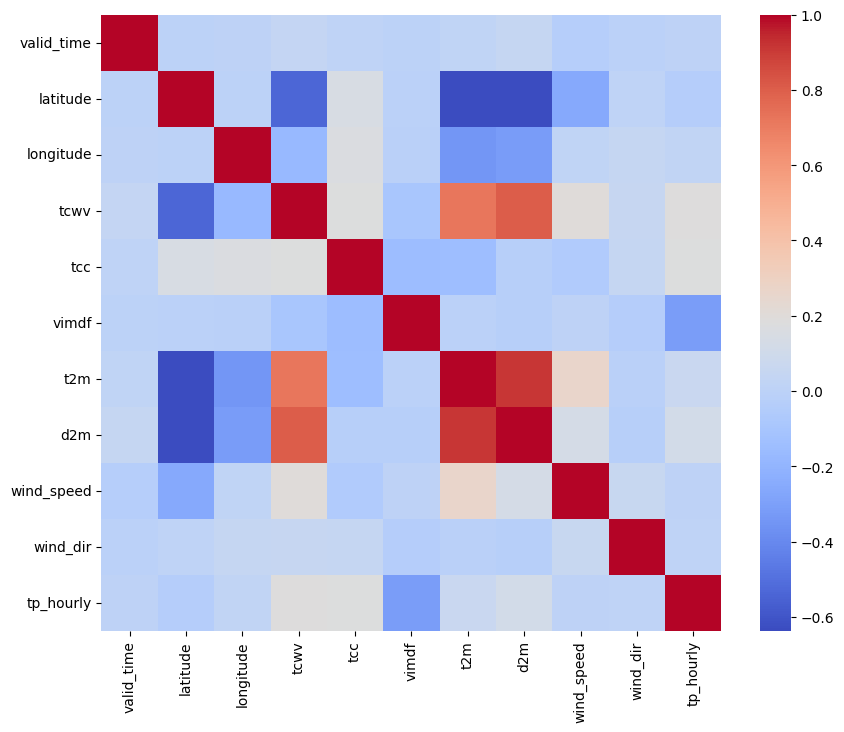

In [ ]:
import seaborn as sns

sample_df = df.sample(100000)  # sample for speed
corr = sample_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26183640 entries, 2928 to 26180711
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   valid_time  datetime64[ns]
 1   latitude    float64       
 2   longitude   float64       
 3   tcwv        float32       
 4   tcc         float32       
 5   vimdf       float32       
 6   t2m         float64       
 7   d2m         float64       
 8   wind_speed  float32       
 9   wind_dir    float32       
 10  tp_hourly   float32       
dtypes: datetime64[ns](1), float32(6), float64(4)
memory usage: 1.8 GB


In [ ]:
df.to_parquet("processed_era5.parquet")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/Preprocessed_era5.parquet")

###Converting Regression to a classification problem

In [ ]:
df_nonzero = df[df["tp_hourly"] > 0]["tp_hourly"]
print(df_nonzero.describe())
df_nonzero.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    5.542145e+06
mean     2.056598e-01
std      5.752064e-01
min      2.384186e-04
25%      4.768372e-03
50%      3.051758e-02
75%      1.454353e-01
max      4.246521e+01
Name: tp_hourly, dtype: float64


,tp_hourly
0.10,0.000954
0.25,0.004768
0.50,0.030518
0.75,0.145435
0.90,0.494957
0.99,2.789974


In [ ]:
import numpy as np

bins = [-0.001, 0, 0.1, np.inf]
labels = [0, 1, 2]  # numeric directly

df["rain_class"] = pd.cut(
    df["tp_hourly"],
    bins=bins,
    labels=labels
).astype(int)

In [ ]:
df["rain_class"].value_counts(normalize=True)

,proportion
rain_class,
0,0.788336
1,0.146230
2,0.065435


In [ ]:
df = df.drop(columns=["tp_hourly"])

In [ ]:
print(df["rain_class"].unique())

[0 1 2]


### Preparing data to fed into ConvLSTM

In [ ]:
df = df.sort_values(by=['valid_time', 'latitude', 'longitude'])

In [ ]:
channels = ['tcwv', 'tcc', 'vimdf', 't2m', 'd2m', 'wind_speed', 'wind_dir', 'rain_class']

In [ ]:
import numpy as np

# Ensure proper ordering
df = df.sort_values(['valid_time', 'latitude', 'longitude'])

# Dimensions
times = df['valid_time'].nunique()
lat = df['latitude'].nunique()
lon = df['longitude'].nunique()
channels = channels  # your list

# Extract values directly
data = df[channels].values.astype(np.float32)

# reshape directly
X = data.reshape(times, lat, lon, len(channels))
X = np.transpose(X, (0, 3, 1, 2))  # (T, C, H, W)

del df
import gc; gc.collect()

0

In [ ]:
print(X.shape)

(8760, 8, 49, 61)


## should try on precipitation

### Preparing Data for CNN Model

In [ ]:
'''import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# Identify the index for 'tp_hourly' in the channels list
tp_hourly_channel_idx = channels.index('rain_class')

# Separate features and target
# y_target will be 'tp_hourly' data
y_target_full = X[:, tp_hourly_channel_idx:tp_hourly_channel_idx+1, :, :] # Keep channel dimension
X_features_full = X

print(f"Shape of X_features_full: {X_features_full.shape}")
print(f"Shape of y_target_full: {y_target_full.shape}")


LOOK_BACK = 4             # past timesteps
PREDICTION_HORIZON = 1    # predict t+1
BATCH_SIZE = 16

X_seq = []
y_seq = []

T = X_features_full.shape[0]

for i in range(T - LOOK_BACK - PREDICTION_HORIZON + 1):

    # Input: past LOOK_BACK timesteps
    x = X_features_full[i : i + LOOK_BACK]   # (LOOK_BACK, C, H, W)

    # Target: next timestep
    y = y_target_full[i + LOOK_BACK]         # (1, H, W)

    # # Flatten time into channels for CNN
    x = x.reshape(-1, x.shape[2], x.shape[3])  # (LOOK_BACK*C, H, W)

    X_seq.append(x)
    y_seq.append(y)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("After sequence creation:")
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

train_ratio = 0.7
val_ratio = 0.15

N = X_seq.shape[0]

train_end = int(N * train_ratio)
val_end = int(N * (train_ratio + val_ratio))

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

#Fixing shape for CE loss
y_train = y_train.squeeze(1)  # (N, H, W)
y_val = y_val.squeeze(1)
y_test = y_test.squeeze(1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

import torch

EPOCHS = 10

train_losses = []
val_losses = []

best_val_loss = float('inf')

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)  # (N, 4, H, W)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ===== PRINT =====
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

#LSTM
T = len(X_features_full)

train_ratio = 0.7
val_ratio = 0.15

train_end = int(T * train_ratio)
val_end   = int(T * (train_ratio + val_ratio))

# Split
X_train = X_features_full[:train_end]
y_train = y_target_full[:train_end]

X_val = X_features_full[train_end:val_end]
y_val = y_target_full[train_end:val_end]

X_test = X_features_full[val_end:]
y_test = y_target_full[val_end:]

#STANDARDIZATION
rain_class_channel = 5

# Compute on train only
mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
std  = X_train.std(axis=(0, 2, 3), keepdims=True) + 1e-6

# normalize all
X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

# restore categorical channel
X_train[:, rain_class_channel] = X_features_full[:train_end, rain_class_channel]
X_val[:, rain_class_channel]   = X_features_full[train_end:val_end, rain_class_channel]
X_test[:, rain_class_channel]  = X_features_full[val_end:, rain_class_channel]
'''
print()

Now, let's create sequences for our time series prediction. We'll define a `look_back` window for input features and `prediction_horizon` for the target variable.

In [ ]:
import torch
from torch.utils.data import Dataset

class ERA5Dataset(Dataset):
    def __init__(self, X, look_back=4):
        self.X = X
        self.look_back = look_back
        self.target_idx = channels.index('rain_class')

    def __len__(self):
        return len(self.X) - self.look_back

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.look_back]   # (L, C, H, W)
        y = self.X[idx + self.look_back, self.target_idx]  # (H, W)

        # flatten time into channels
        x = x.reshape(-1, x.shape[2], x.shape[3])  # (L*C, H, W)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [ ]:
from torch.utils.data import Subset
look_back = 4
dataset = ERA5Dataset(X, look_back)

N = len(dataset)

train_ratio = 0.7
val_ratio = 0.15

train_end = int(N * train_ratio)
val_end = int(N * (train_ratio + val_ratio))

train_dataset = Subset(dataset, range(0, train_end))
val_dataset   = Subset(dataset, range(train_end, val_end))
test_dataset  = Subset(dataset, range(val_end, N))

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print(f"Number of features (channels): {X.shape[1]}")
print(f"Input sequence length: {look_back}")
print(f"Latitude dimensions: {X.shape[2]}")
print(f"Longitude dimensions: {X.shape[3]}")

effective_samples = len(dataset)

print("\n--- After sequencing ---")
print(f"Final input channels (LOOK_BACK * features): {look_back * X.shape[1]}")
print(f"Effective samples (after sequencing): {effective_samples}")
print(f"Input per sample shape: ({look_back * X.shape[1]}, {X.shape[2]}, {X.shape[3]})")
print(f"Target per sample shape: ({X.shape[2]}, {X.shape[3]})")

print("\n--- Dataset splits ---")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

print("\n--- Batch check ---")

for xb, yb in train_loader:
    print(f"Batch X shape: {xb.shape}")  # (B, L*C, H, W)
    print(f"Batch y shape: {yb.shape}")  # (B, H, W)
    break


Number of features (channels): 8
Input sequence length: 4
Latitude dimensions: 49
Longitude dimensions: 61

--- After sequencing ---
Final input channels (LOOK_BACK * features): 32
Effective samples (after sequencing): 8756
Input per sample shape: (32, 49, 61)
Target per sample shape: (49, 61)

--- Dataset splits ---
Train samples: 6129
Validation samples: 1313
Test samples: 1314

--- Batch check ---
Batch X shape: torch.Size([16, 32, 49, 61])
Batch y shape: torch.Size([16, 49, 61])


### Preparing Data for CNN Model

### Defining the CNN Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RainCNN(nn.Module):
    def __init__(self, in_channels, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # x: (N, C, H, W)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.relu(self.bn4(self.conv4(x)))

        x = self.out(x)  # (N, num_classes, H, W)

        return x

in_channels = 32
model = RainCNN(in_channels=in_channels, num_classes=3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)

RainCNN(
  (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
)


### Training the CNN Model

In [ ]:
def compute_class_weights(dataset, num_classes=3, max_samples=None):
    counts = np.zeros(num_classes)

    for i in range(len(dataset)):
        _, y = dataset[i]   # y shape: (H, W)

        y_np = y.numpy()
        unique, freq = np.unique(y_np, return_counts=True)

        for u, f in zip(unique, freq):
            counts[int(u)] += f

        # Optional: stop early for speed
        if max_samples and i >= max_samples:
            break

    # Avoid division by zero
    counts = np.maximum(counts, 1)

    # Your original logic (sqrt smoothing)
    weights = 1.0 / np.sqrt(counts)

    # Normalize (optional but good practice)
    weights = weights / weights.sum() * num_classes

    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_dataset, num_classes=3)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
class_weights

In [ ]:
import torch

EPOCHS = 10

train_losses = []
val_losses = []

best_val_loss = float('inf')

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(X_batch)  # (B, num_classes, H, W)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ===== SAVE BEST MODEL =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "cnn_model.pth")

    # ===== PRINT =====
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [1/10] | Train Loss: 0.7732 | Val Loss: 0.8652
Epoch [2/10] | Train Loss: 0.7292 | Val Loss: 0.8035
Epoch [3/10] | Train Loss: 0.7260 | Val Loss: 0.7943
Epoch [4/10] | Train Loss: 0.7263 | Val Loss: 0.8316
Epoch [5/10] | Train Loss: 0.7177 | Val Loss: 0.7961
Epoch [6/10] | Train Loss: 0.7067 | Val Loss: 0.8003
Epoch [7/10] | Train Loss: 0.6937 | Val Loss: 0.8003
Epoch [8/10] | Train Loss: 0.6857 | Val Loss: 0.7775
Epoch [9/10] | Train Loss: 0.6763 | Val Loss: 0.7691
Epoch [10/10] | Train Loss: 0.6682 | Val Loss: 0.7598


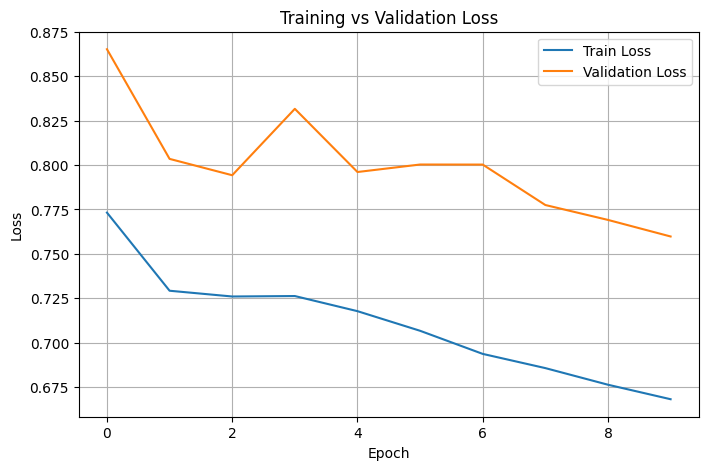

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

### Evaluating the CNN Model

In [ ]:
model.eval()

test_loss = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)  # (N, 4, H, W)

        loss = criterion(outputs, y_batch)
        test_loss += loss.item()

        # predictions
        preds = torch.argmax(outputs, dim=1)  # (N, H, W)

        all_preds.append(preds.cpu())
        all_targets.append(y_batch.cpu())

test_loss /= len(test_loader)

# concatenate all batches
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

print(f"Test Loss: {test_loss:.4f}")


Test Loss: 0.6794


In [ ]:
correct = (all_preds == all_targets).float().mean()
print(f"Pixel Accuracy: {correct:.4f}")

Pixel Accuracy: 0.7034


In [ ]:
from sklearn.metrics import classification_report

y_true = all_targets.numpy().flatten()
y_pred = all_preds.numpy().flatten()

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9047    0.7783    0.8368   3130385
           1     0.4301    0.2326    0.3019    538583
           2     0.2131    0.7776    0.3346    258578

    accuracy                         0.7034   3927546
   macro avg     0.5160    0.5962    0.4911   3927546
weighted avg     0.7941    0.7034    0.7304   3927546



Predictions shape: torch.Size([1314, 49, 61])
Targets shape: torch.Size([1314, 49, 61])


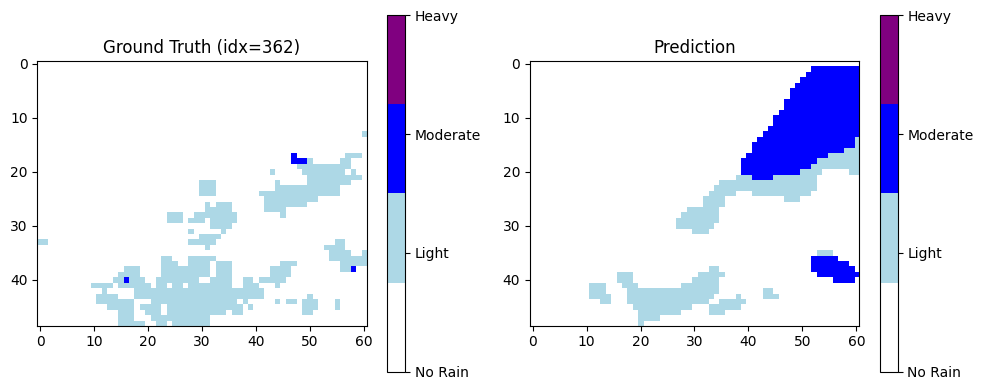

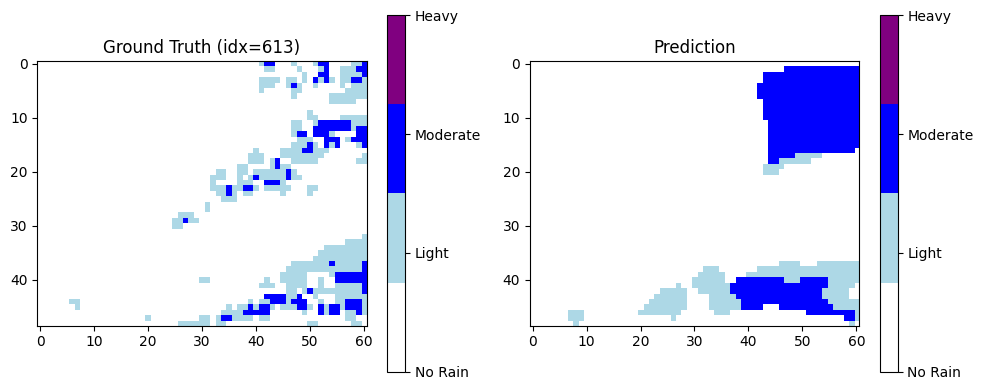

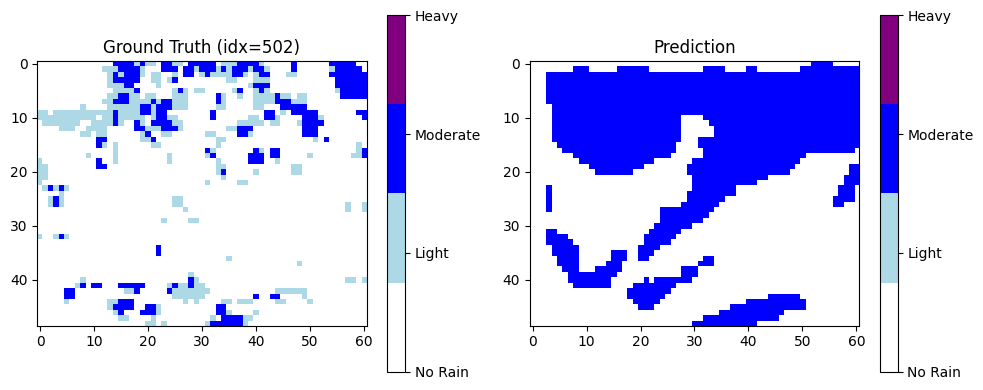

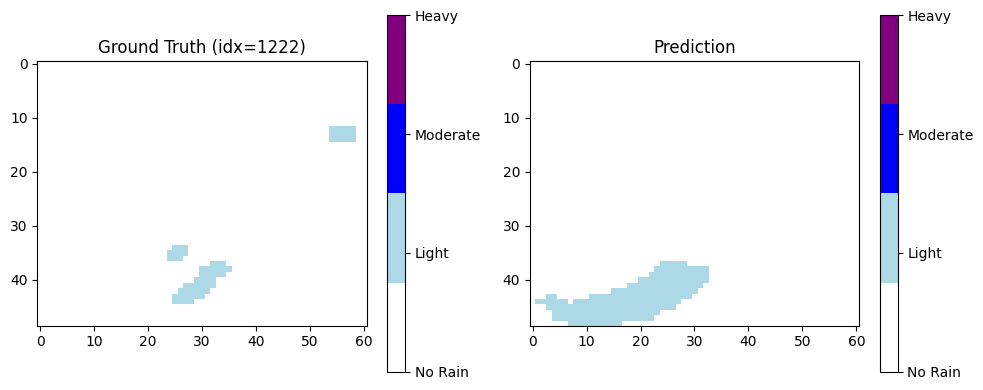

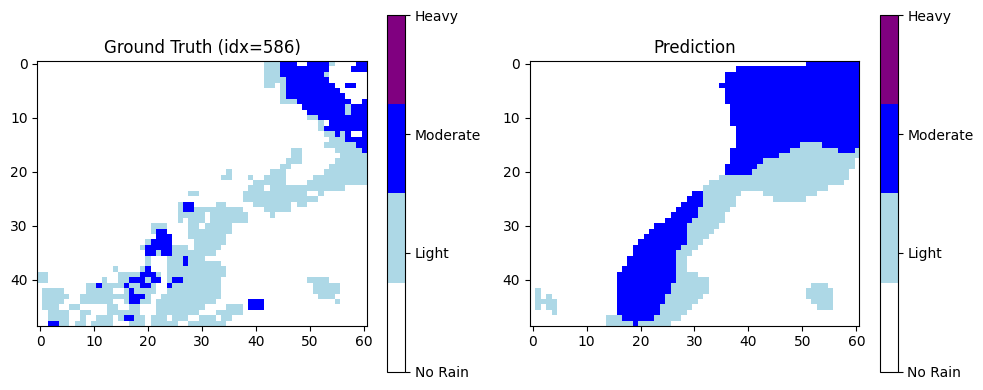

In [ ]:
# We see poor accuracy for CNNs
from matplotlib.colors import ListedColormap

# ===== Step 1: Get predictions on full test set =====
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_targets.append(y_batch.cpu())

# Concatenate all batches
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

print("Predictions shape:", all_preds.shape)
print("Targets shape:", all_targets.shape)

# ===== Step 2: Define colormap =====
cmap = ListedColormap(['white', 'lightblue', 'blue', 'purple'])
class_names = ['No Rain', 'Light', 'Moderate', 'Heavy']

# ===== Step 3: Plot random samples =====
def plot_random_samples(y_true, y_pred, num_samples=5):

    total = y_true.shape[0]
    indices = np.random.choice(total, num_samples, replace=False)

    for i in indices:
        plt.figure(figsize=(10,4))

        # Ground Truth
        plt.subplot(1,2,1)
        plt.imshow(y_true[i], cmap=cmap, vmin=0, vmax=3)
        plt.title(f"Ground Truth (idx={i})")
        cbar = plt.colorbar(ticks=[0,1,2,3])
        cbar.ax.set_yticklabels(class_names)

        # Prediction
        plt.subplot(1,2,2)
        plt.imshow(y_pred[i], cmap=cmap, vmin=0, vmax=3)
        plt.title("Prediction")
        cbar = plt.colorbar(ticks=[0,1,2,3])
        cbar.ax.set_yticklabels(class_names)

        plt.tight_layout()
        plt.show()

# ===== Step 4: Call function =====
plot_random_samples(all_targets, all_preds, num_samples=5)

The model is biased toward predicting rare heavy rain events, resulting in poor precision and reduced overall reliability. This highlights limitations of the CNN baseline in handling class imbalance and capturing meaningful spatiotemporal patterns.

For Normal

                 precision  recall    f1-score  support
           0     0.8624     0.4181    0.5632    484140
           1     0.2751     0.4007    0.3262    108979
           2     0.2210     0.1842    0.2010     57137
           3     0.0166     0.8168    0.0325      4335

    accuracy                             0.3975    654591
    macro avg        0.3438    0.4550    0.2807    654591
    weighted avg     0.7031    0.3975    0.4886    654591

For SQRT

                 precision  recall    f1-score  support
           0     0.8718    0.8618     0.8667    3130385
           1     0.4015    0.3041     0.3461    538583
           2     0.3023    0.4971     0.3760    258578

    accuracy                           0.7613   3927546
    macro avg     0.5252     0.5543    0.5296   3927546
    weighted avg  0.7698     0.7613    0.7630   3927546


### Preparing Data for Standard LSTM Model

In [ ]:
import torch

class RainDataset(torch.utils.data.Dataset):
    def __init__(self, X, look_back=24, input_channels=None, target_idx=None):
        self.X = X
        self.look_back = look_back
        self.input_channels = input_channels
        self.target_idx = target_idx

    def __len__(self):
        return len(self.X) - self.look_back

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.look_back]   # (T, C, H, W)

        # select only input channels
        x = x[:, self.input_channels]

        # flatten for LSTM
        x = x.reshape(self.look_back, -1)

        y = self.X[idx + self.look_back, self.target_idx]  # (H, W)
        y = y.reshape(-1)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [ ]:
import numpy as np
import torch
from torch.utils.data import Subset

# ===== CONFIG =====
look_back = 24
target_idx = 7
input_channels = [0,1,2,3,4,5,6]

# ===== DIMENSIONS =====
T = len(X)
N = T - look_back   # effective samples after sequencing

# ===== SPLITS =====
train_end = int(0.7 * N)
val_end   = int(0.85 * N)

# ===== NORMALIZATION (TRAIN ONLY) =====
mean = X[:train_end].mean(axis=(0,2,3), keepdims=True)
std  = X[:train_end].std(axis=(0,2,3), keepdims=True) + 1e-6

# ===== NORMALIZE ONLY INPUT CHANNELS =====
mask = np.ones(X.shape[1], dtype=bool)
mask[target_idx] = False

X[:, mask] = (X[:, mask] - mean[:, mask]) / std[:, mask]

# ===== DATASET =====
dataset = RainDataset(
    X,
    look_back=look_back,
    input_channels=input_channels,
    target_idx=target_idx
)

# ===== SPLIT USING INDICES =====
train_dataset = Subset(dataset, range(0, train_end))
val_dataset   = Subset(dataset, range(train_end, val_end))
test_dataset  = Subset(dataset, range(val_end, N))

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
#Sanity Check
for xb, yb in train_loader:
    print("X:", xb.shape)  # (B, T, features)
    print("y:", yb.shape)  # (B, pixels)
    break

X: torch.Size([16, 24, 20923])
y: torch.Size([16, 2989])


In [ ]:
'''import torch
from torch.utils.data import Dataset

class RainDataset(Dataset):
    def __init__(self, X, y, seq_len=24):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx+self.seq_len]
        x_seq = x_seq.view(self.seq_len, -1)

        y_target = self.y[idx+self.seq_len]
        y_target = y_target.view(-1)

        return x_seq, y_target

from torch.utils.data import DataLoader

seq_len = 24
batch_size = 16

train_dataset = RainDataset(X_train, y_train, seq_len)
val_dataset   = RainDataset(X_val, y_val, seq_len)
test_dataset  = RainDataset(X_test, y_test, seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)   # (batch, seq_len, features)
print(y_batch.shape)   # (batch, 2989)

print(y_batch.dtype)
print(torch.unique(y_batch))'''
print()

### Defining the Standard LSTM Model

In [ ]:
import torch.nn as nn

class RainLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=3, num_classes=3):
        super().__init__()

        # Encode large input → smaller feature
        # It is used so we don't end up with a very huge weight matrix
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # LSTM
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        # Output head → pixel-wise classification
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 49*61*num_classes)
        )

        self.num_classes = num_classes

    def forward(self, x):
        B, T, F = x.shape

        # Encode each timestep
        x = x.view(B*T, F)
        x = self.encoder(x)
        x = x.view(B, T, -1)

        # LSTM
        out, _ = self.lstm(x)

        # Last timestep
        out = out[:, -1, :]

        # Head
        out = self.head(out)

        # Reshape → (B, classes, pixels)
        out = out.view(B, self.num_classes, -1)

        return out

# RE-INSTANTIATE the model to apply the fix
sample_x, _ = next(iter(train_loader))
input_size = sample_x.shape[-1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RainLSTM(input_size).to(device)

print(model)

RainLSTM(
  (encoder): Sequential(
    (0): Linear(in_features=20923, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(512, 256, num_layers=3, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=8967, bias=True)
  )
)


### Training the Standard LSTM Model

In [ ]:
import numpy as np
import torch
import torch.nn as nn

def compute_class_weights(dataset, num_classes=3, max_samples=1000):
    counts = np.zeros(num_classes, dtype=np.float64)

    for i in range(len(dataset)):
        _, y = dataset[i]   # y shape: (pixels,)

        y_np = y.numpy()
        unique, freq = np.unique(y_np, return_counts=True)

        for u, f in zip(unique, freq):
            if 0 <= u < num_classes:   # safety check
                counts[int(u)] += f

        # stop early for speed
        if max_samples is not None and i >= max_samples - 1:
            break

    # Avoid division by zero
    counts = np.maximum(counts, 1)

    # ===== Weighting strategy =====
    # Option 1 (stable, recommended)
    weights = 1.0 / np.sqrt(counts)

    # ----- Alternative (stronger balancing) -----
    # median = np.median(counts)
    # weights = median / counts

    # Normalize weights
    weights = weights / weights.sum() * num_classes

    weights = torch.tensor(weights, dtype=torch.float32)

    print("Class counts:", counts)
    print("Class weights:", weights)

    return weights

In [ ]:
class_weights = compute_class_weights(
    train_dataset,
    num_classes=3,
    max_samples=1000   # fast + sufficient
)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

Class counts: [2523584.  366882.   98534.]
Class weights: tensor([0.3455, 0.9061, 1.7484])


In [ ]:
sample_x, sample_y = next(iter(train_loader))
out = model(sample_x.to(device))

print("Output shape:", out.shape)
print("Target shape:", sample_y.shape)

Output shape: torch.Size([16, 3, 2989])
Target shape: torch.Size([16, 2989])


In [ ]:
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()

        outputs = model(X_batch)  # (B, 3, 2989)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_acc += (preds == y_batch).float().mean().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.8720 | Val Loss: 1.0203 | Val Acc: 0.6849
Epoch 2/10 | Train Loss: 0.8839 | Val Loss: 1.0697 | Val Acc: 0.6731
Epoch 3/10 | Train Loss: 0.9125 | Val Loss: 1.0010 | Val Acc: 0.7353
Epoch 4/10 | Train Loss: 0.9238 | Val Loss: 0.9802 | Val Acc: 0.7280
Epoch 5/10 | Train Loss: 0.9257 | Val Loss: 0.9731 | Val Acc: 0.7246
Epoch 6/10 | Train Loss: 0.9235 | Val Loss: 1.0043 | Val Acc: 0.7367
Epoch 7/10 | Train Loss: 0.9263 | Val Loss: 0.9687 | Val Acc: 0.7200
Epoch 8/10 | Train Loss: 0.9244 | Val Loss: 0.9679 | Val Acc: 0.7227
Epoch 9/10 | Train Loss: 0.9264 | Val Loss: 0.9658 | Val Acc: 0.7215
Epoch 10/10 | Train Loss: 0.9247 | Val Loss: 0.9658 | Val Acc: 0.7231


### Evaluating the Standard LSTM Model

In [ ]:
model.eval()

test_loss = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        outputs = model(X_batch)              # (B, 4, 2989)

        loss = criterion(outputs, y_batch)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)  # (B, 2989)

        all_preds.append(preds.cpu())
        all_targets.append(y_batch.cpu())

test_loss /= len(test_loader)

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

print(f"Test Loss: {test_loss:.4f}")

# Pixel accuracy
correct = (all_preds == all_targets).float().mean()
print(f"Pixel Accuracy: {correct:.4f}")


Test Loss: 0.9144
Pixel Accuracy: 0.7398


In [ ]:
from sklearn.metrics import classification_report

y_true = all_targets.numpy().flatten()
y_pred = all_preds.numpy().flatten()

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8136    0.8893    0.8498   3124530
           1     0.2534    0.1986    0.2227    536883
           2     0.1667    0.0535    0.0811    257166

    accuracy                         0.7398   3918579
   macro avg     0.4113    0.3805    0.3845   3918579
weighted avg     0.6944    0.7398    0.7134   3918579



In [ ]:
H, W = 49, 61

all_preds_2d = all_preds.view(-1, H, W)
all_targets_2d = all_targets.view(-1, H, W)

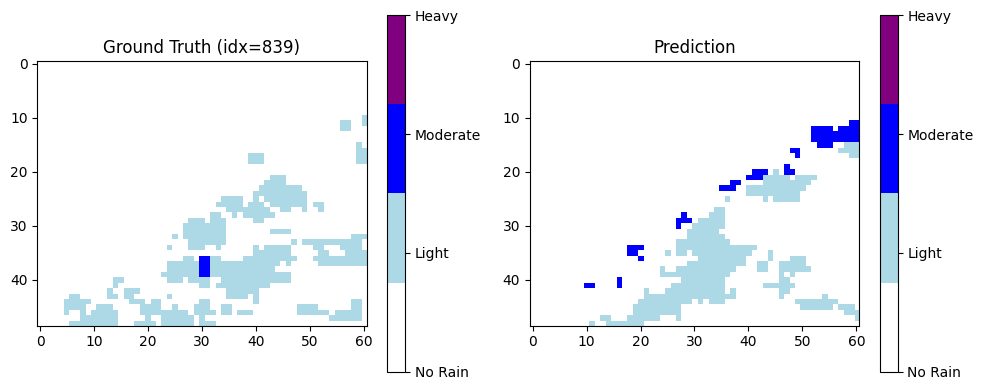

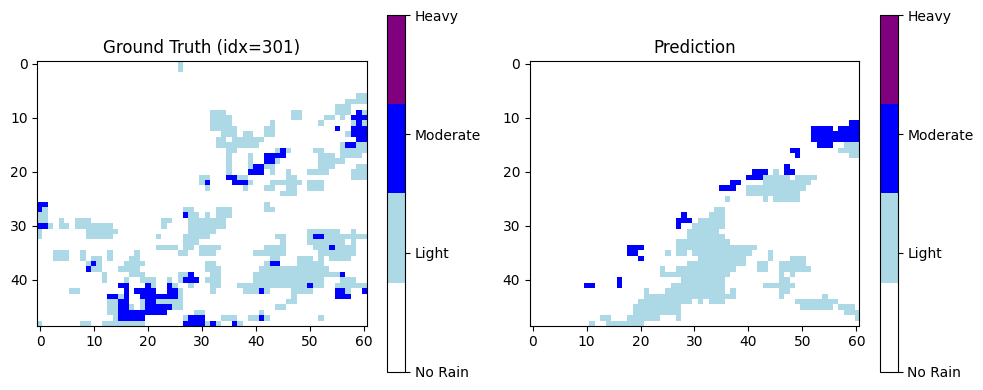

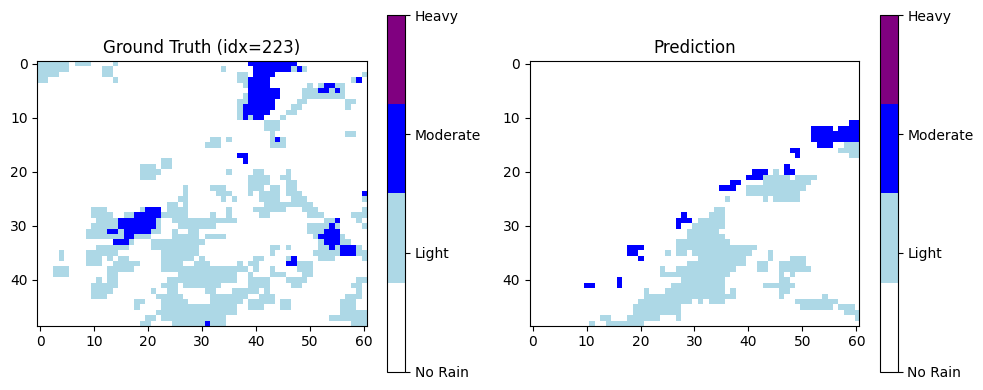

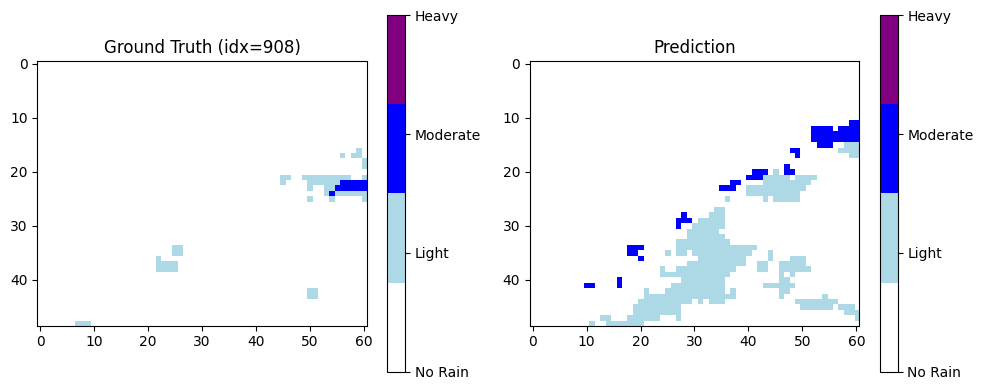

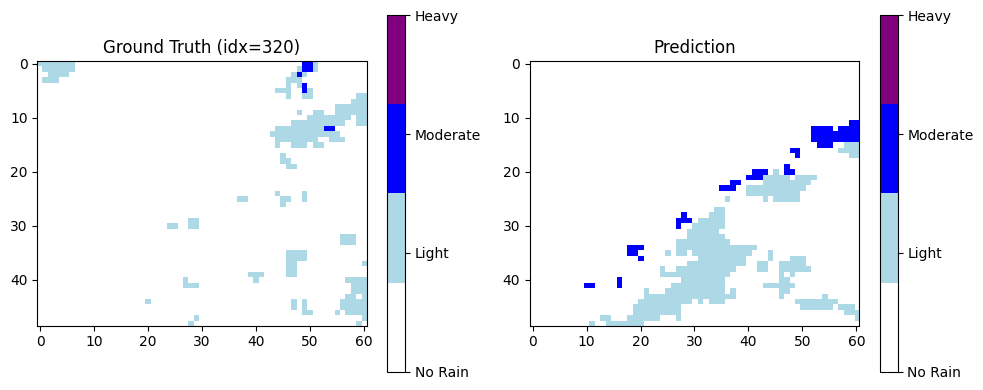

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

cmap = ListedColormap(['white', 'lightblue', 'blue', 'purple'])
class_names = ['No Rain', 'Light', 'Moderate', 'Heavy']

def plot_random_samples(y_true, y_pred, num_samples=5):
    total = y_true.shape[0]
    indices = np.random.choice(total, num_samples, replace=False)

    for i in indices:
        plt.figure(figsize=(10,4))

        # Ground Truth
        plt.subplot(1,2,1)
        plt.imshow(y_true[i], cmap=cmap, vmin=0, vmax=3)
        plt.title(f"Ground Truth (idx={i})")
        cbar = plt.colorbar(ticks=[0,1,2,3])
        cbar.ax.set_yticklabels(class_names)

        # Prediction
        plt.subplot(1,2,2)
        plt.imshow(y_pred[i], cmap=cmap, vmin=0, vmax=3)
        plt.title("Prediction")
        cbar = plt.colorbar(ticks=[0,1,2,3])
        cbar.ax.set_yticklabels(class_names)

        plt.tight_layout()
        plt.show()


plot_random_samples(all_targets_2d, all_preds_2d, num_samples=5)

Basically we saw that there is a class imbalance and this is creating all sorts of problems.

* Using Normal CELoss makes model predict everything as no rainfall (~73% is 0 class so 73% accuracy)
* Using focal loss with gamma 1 and 2 gives accuracy 4% and 15% respectively.
* Using Weighted CELoss gives a little better accuracy so that is the one we will be using.
  * Using inverse frequency makes model aggresively predict the rarer classes. We get the following results:
    *               precision    recall  f1-score   support

           0     0.9194    0.2103    0.3423    431103
           1     0.2126    0.3243    0.2568     98581
           2     0.1218    0.2808    0.1699     52167
           3     0.0160    0.8693    0.0315      3993

            accuracy                         0.2402    585844
            macro avg     0.3174    0.4211    0.2001    585844
            weighted avg     0.7232    0.2402    0.3104    585844
  * Now we use inverse SQRT weights
    *              precision    recall  f1-score   support

           0     0.8316    0.6985    0.7592    431103
           1     0.2858    0.3047    0.2950     98581
           2     0.2067    0.4406    0.2814     52167
           3     0.0447    0.0831    0.0581      3993

           accuracy                         0.6051    585844
           macro avg     0.3422    0.3817    0.3484    585844
          weighted avg     0.6787    0.6051    0.6338    585844


##Preparing Data for ConvLSTM Model

In [ ]:
'''import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# Identify the index for 'tp_hourly' in the channels list
tp_hourly_channel_idx = channels.index('rain_class')

# Separate features and target
# y_target will be 'tp_hourly' data
y_target_full = X[:, tp_hourly_channel_idx:tp_hourly_channel_idx+1, :, :] # Keep channel dimension
X_features_full = X

print(f"Shape of X_features_full: {X_features_full.shape}")
print(f"Shape of y_target_full: {y_target_full.shape}")
LOOK_BACK = 16            # past timesteps
PREDICTION_HORIZON = 1    # predict t+1
BATCH_SIZE = 16

X_seq = []
y_seq = []

T = X_features_full.shape[0]

for i in range(T - LOOK_BACK - PREDICTION_HORIZON + 1):

    # Input: past LOOK_BACK timesteps
    x = X_features_full[i : i + LOOK_BACK]   # (LOOK_BACK, C, H, W)

    # Target: next timestep
    y = y_target_full[i + LOOK_BACK]         # (1, H, W)

    # # Flatten time into channels for CNN
    #x = x.reshape(-1, x.shape[2], x.shape[3])  # (LOOK_BACK*C, H, W)

    X_seq.append(x)
    y_seq.append(y)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("After sequence creation:")
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

train_ratio = 0.7
val_ratio = 0.15

N = X_seq.shape[0]

train_end = int(N * train_ratio)
val_end = int(N * (train_ratio + val_ratio))

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

#Fixing shape for CE loss
y_train = y_train.squeeze(1)  # (N, H, W)
y_val = y_val.squeeze(1)
y_test = y_test.squeeze(1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
'''
print()

Shape of X_features_full: (1464, 6, 49, 61)
Shape of y_target_full: (1464, 1, 49, 61)


In [ ]:
tp_idx = channels.index('rain_class')

X_input = X              # (T, 8, H, W)
y_full  = X[:, tp_idx]   # (T, H, W)

In [ ]:
X_norm = X.copy()

for i, ch in enumerate(channels):
    if ch != 'rain_class':
        mean = X[:, i].mean()
        std  = X[:, i].std() + 1e-6
        X_norm[:, i] = (X[:, i] - mean) / std

In [ ]:
import torch

class RainDataset(torch.utils.data.Dataset):
    def __init__(self, X, target_idx, look_back=16):
        self.X = torch.from_numpy(X).float()
        self.target_idx = target_idx
        self.L = look_back
        self.T = X.shape[0]

    def __len__(self):
        return self.T - self.L

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.L]                 # (L, C, H, W)
        y = self.X[idx + self.L, self.target_idx]      # (H, W)
        return x, y.long()

In [ ]:
from torch.utils.data import DataLoader, Subset

# Full dataset
dataset = RainDataset(X_norm, tp_idx, look_back=16)

# Sizes
N = len(dataset)
train_end = int(0.7 * N)
val_end   = int(0.85 * N)

# Subsets (NO data copy)
train_ds = Subset(dataset, range(0, train_end))
val_ds   = Subset(dataset, range(train_end, val_end))
test_ds  = Subset(dataset, range(val_end, N))

In [ ]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

In [ ]:
del data
del X

In [ ]:
import gc
gc.collect()

30

In [ ]:
print("\n--- Data summary ---")

# From X_norm (your final tensor)
print(f"Total timesteps (T): {X_norm.shape[0]}")
print(f"Number of channels (C): {X_norm.shape[1]}")
print(f"Latitude (H): {X_norm.shape[2]}")
print(f"Longitude (W): {X_norm.shape[3]}")

print(f"Input sequence length (LOOK_BACK): {16}")  # or your variable
print(f"Prediction horizon: 1 (next timestep rain_class)")

print("\n--- Dataset splits ---")
print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

print("\n--- Batch check ---")

xb, yb = next(iter(train_loader))

print(f"Batch X shape: {xb.shape}")
print(f"Batch y shape: {yb.shape}")


--- Data summary ---
Total timesteps (T): 8760
Number of channels (C): 8
Latitude (H): 49
Longitude (W): 61
Input sequence length (LOOK_BACK): 16
Prediction horizon: 1 (next timestep rain_class)

--- Dataset splits ---
Train samples: 6120
Validation samples: 1312
Test samples: 1312

--- Batch check ---
Batch X shape: torch.Size([8, 16, 8, 49, 61])
Batch y shape: torch.Size([8, 49, 61])


### ConvLSTM model Exp 1
* Simple Model
* Simple Loss
* Moderate training

In [ ]:
import torch
import torch.nn as nn

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=padding
        )

        #  Peephole parameters
        self.Wci = nn.Parameter(torch.zeros(1, hidden_dim, 1, 1))
        self.Wcf = nn.Parameter(torch.zeros(1, hidden_dim, 1, 1))
        self.Wco = nn.Parameter(torch.zeros(1, hidden_dim, 1, 1))

        self.hidden_dim = hidden_dim

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)

        conv_out = self.conv(combined)
        i, f, o, g = torch.chunk(conv_out, 4, dim=1)

        # Add peephole connections
        i = torch.sigmoid(i + self.Wci * c)
        f = torch.sigmoid(f + self.Wcf * c)

        g = torch.tanh(g)

        c_next = f * c + i * g

        o = torch.sigmoid(o + self.Wco * c_next)

        h_next = o * torch.tanh(c_next)

        return h_next, c_next

In [ ]:
from typing import Tuple
class Encoder(nn.Module):
    """ConvLSTM Encoder."""

    def __init__(self, input_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.convlstm = ConvLSTMCell(input_dim, hidden_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x: (batch, time, channels, height, width)
        Returns:
            h, c: Hidden and cell states
        """
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)

        for t in range(T):
            h, c = self.convlstm(x[:, t], h, c)

        return h, c


In [ ]:
class Decoder(nn.Module):
    """ConvLSTM Decoder."""

    def __init__(self, hidden_dim: int, output_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.convlstm = ConvLSTMCell(output_dim, hidden_dim)
        self.output_conv = nn.Conv2d(hidden_dim, output_dim, kernel_size=1)

    def forward(self, h, c, x_init, target_len):
        B, _, H, W = h.shape
        outputs = []

        x = x_init

        for _ in range(target_len):
            h, c = self.convlstm(x, h, c)
            x = self.output_conv(h)
            outputs.append(x)

        return torch.stack(outputs, dim=1)

In [ ]:
import torch.nn.functional as F

class ConvLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=32, rain_channel_idx=7):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim)
        self.decoder = Decoder(hidden_dim, num_classes)
        self.rain_channel_idx = rain_channel_idx
        self.num_classes = num_classes

    def forward(self, x, target_len=1):
        h, c = self.encoder(x)

        # (B, H, W)
        x_init = x[:, -1, self.rain_channel_idx]

        x_init = F.one_hot(
            x_init.long(), num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        out = self.decoder(h, c, x_init, target_len)
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvLSTMSeq2Seq(
    input_dim=8,
    num_classes=3,
    hidden_dim=32,
    rain_channel_idx=7
).to(device)

print(model)  # sanity check

ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(40, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(35, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (output_conv): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [ ]:
import numpy as np
import torch

def compute_class_weights_from_X(X_norm, tp_idx, look_back=16, num_classes=3, max_samples=1000):
    counts = np.zeros(num_classes, dtype=np.float64)

    T = X_norm.shape[0]

    N = T - look_back  # number of samples

    for i in range(N):
        t = i + look_back   # target timestep

        y = X_norm[t, tp_idx]   # (H, W)

        unique, freq = np.unique(y.astype(int), return_counts=True)

        for u, f in zip(unique, freq):
            if 0 <= u < num_classes:
                counts[u] += f

        if max_samples and i >= max_samples:
            break

    counts = np.maximum(counts, 1)

    # same logic as before
    weights = 1.0 / np.sqrt(counts)

    # normalize
    weights = weights / weights.sum() * num_classes

    return torch.tensor(weights, dtype=torch.float32)

tp_idx = 7

class_weights = compute_class_weights_from_X(
    X_norm,
    tp_idx=tp_idx,
    look_back=16,
    num_classes=3,
    max_samples=1000
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)

            outputs = outputs[:, 0]

            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
import copy

EPOCHS = 100
PATIENCE = 10

best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()

        outputs = model(X_batch, target_len=1)
        outputs = outputs[:, 0]

        loss = criterion(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("Validation improved — model saved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# ===== LOAD BEST MODEL =====
model.load_state_dict(best_model_wts)
print("✅ Best model loaded")


Epoch 1/100
Train Loss: 0.7280 | Val Loss: 0.7151
Validation improved — model saved

Epoch 2/100
Train Loss: 0.6444 | Val Loss: 0.6623
Validation improved — model saved

Epoch 3/100
Train Loss: 0.6121 | Val Loss: 0.6410
Validation improved — model saved

Epoch 4/100
Train Loss: 0.5990 | Val Loss: 0.6354
Validation improved — model saved

Epoch 5/100
Train Loss: 0.5909 | Val Loss: 0.6282
Validation improved — model saved

Epoch 6/100
Train Loss: 0.5854 | Val Loss: 0.6276
Validation improved — model saved

Epoch 7/100
Train Loss: 0.5813 | Val Loss: 0.6187
Validation improved — model saved

Epoch 8/100
Train Loss: 0.5777 | Val Loss: 0.6169
Validation improved — model saved

Epoch 9/100
Train Loss: 0.5752 | Val Loss: 0.6136
Validation improved — model saved

Epoch 10/100
Train Loss: 0.5725 | Val Loss: 0.6132
Validation improved — model saved

Epoch 11/100
Train Loss: 0.5697 | Val Loss: 0.6141
No improvement (1/10)

Epoch 12/100
Train Loss: 0.5693 | Val Loss: 0.6102
Validation improved — m

KeyboardInterrupt: 

In [ ]:
model.load_state_dict(best_model_wts)

<All keys matched successfully>

In [ ]:
xb, _ = next(iter(train_loader))
input_dim = xb.shape[2]

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": 32,      # match your model
    "num_classes": 3       # correct
}, "convlstm_m1_vanilla.pth")

print("Full model checkpoint saved ✔")

Full model checkpoint saved ✔


In [ ]:
model.eval()

ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (cell1): ConvLSTMCell(
      (conv): Conv2d(38, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (cell2): ConvLSTMCell(
      (conv): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (cell3): ConvLSTMCell(
      (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (cell4): ConvLSTMCell(
      (conv): Conv2d(192, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): Decoder(
    (cell1): ConvLSTMCell(
      (conv): Conv2d(129, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

In [ ]:
def predict(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]   # safer

            pred = torch.argmax(outputs, dim=1)

            preds.append(pred.cpu())
            targets.append(y_batch)

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return preds, targets


def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return (correct / total).item()


def class_wise_accuracy(preds, targets, num_classes=3):
    preds = preds.view(-1)
    targets = targets.view(-1)

    for cls in range(num_classes):
        mask = (targets == cls)

        if mask.sum() == 0:
            print(f"Class {cls}: No samples")
            continue

        acc = (preds[mask] == cls).float().mean()
        print(f"Class {cls} Accuracy: {acc:.4f}")


# ===== RUN =====
preds, targets = predict(model, test_loader)

acc = pixel_accuracy(preds, targets)
print(f"\nTest Pixel Accuracy: {acc:.4f}\n")

class_wise_accuracy(preds, targets, num_classes=3)


Test Pixel Accuracy: 0.7887

Class 0 Accuracy: 0.8348
Class 1 Accuracy: 0.5430
Class 2 Accuracy: 0.7421


In [ ]:
from sklearn.metrics import classification_report

# flatten
preds_flat = preds.view(-1).numpy()
targets_flat = targets.view(-1).numpy()

report = classification_report(
    targets_flat,
    preds_flat,
    labels=[0, 1, 2],
    target_names=["No Rain", "Light Rain", "Heavy Rain"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

     No Rain     0.9421    0.8348    0.8852   3126411
  Light Rain     0.4797    0.5430    0.5094    537482
  Heavy Rain     0.3523    0.7421    0.4778    257675

    accuracy                         0.7887   3921568
   macro avg     0.5913    0.7066    0.6241   3921568
weighted avg     0.8399    0.7887    0.8069   3921568



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap

def plot_predictions_loader(model, loader, device, num_samples=5):
    model.eval()

    # ===== Colormap (adapted to 3 classes) =====
    cmap = ListedColormap(['white', 'lightblue', 'blue'])
    class_names = ['No Rain', 'Light Rain', 'Heavy Rain']

    all_preds = []
    all_targets = []

    # ===== Collect predictions =====
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    print("Predictions shape:", all_preds.shape)
    print("Targets shape:", all_targets.shape)

    # ===== Plot random samples =====
    total = all_targets.shape[0]
    indices = np.random.choice(total, num_samples, replace=False)

    for i in indices:
        plt.figure(figsize=(10, 4))

        # Ground truth
        plt.subplot(1, 2, 1)
        plt.imshow(all_targets[i], cmap=cmap, vmin=0, vmax=2)
        plt.title(f"Ground Truth (idx={i})")
        cbar = plt.colorbar(ticks=[0, 1, 2])
        cbar.ax.set_yticklabels(class_names)

        # Prediction
        plt.subplot(1, 2, 2)
        plt.imshow(all_preds[i], cmap=cmap, vmin=0, vmax=2)
        plt.title("Prediction")
        cbar = plt.colorbar(ticks=[0, 1, 2])
        cbar.ax.set_yticklabels(class_names)

        plt.tight_layout()
        plt.show()

Predictions shape: torch.Size([1312, 49, 61])
Targets shape: torch.Size([1312, 49, 61])


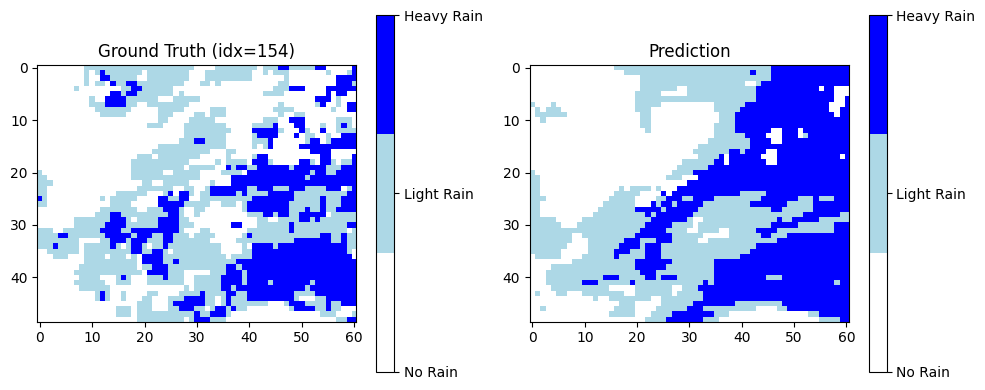

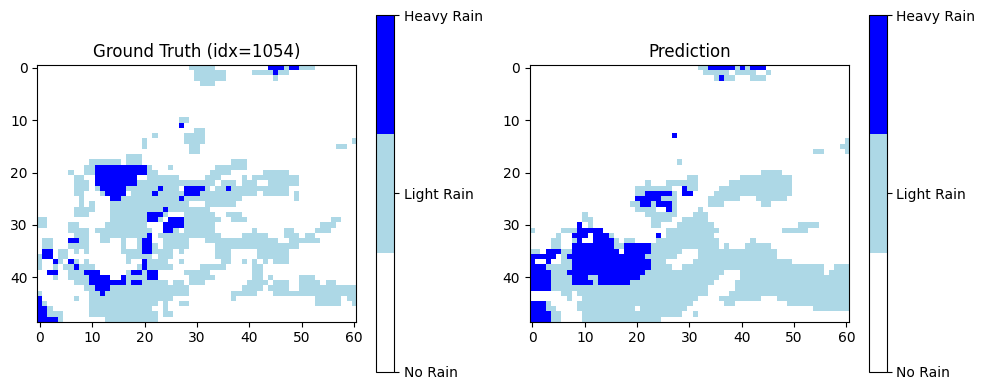

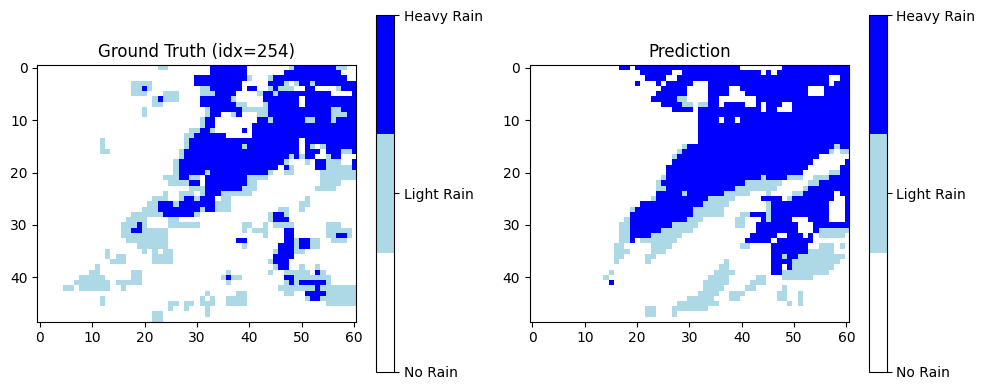

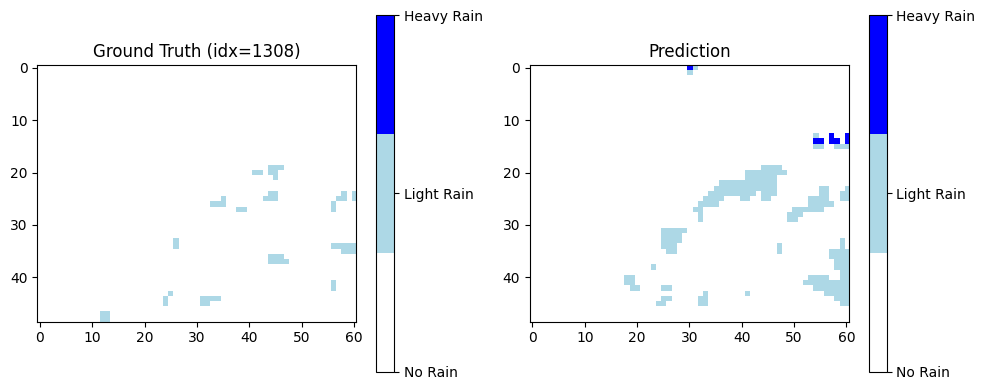

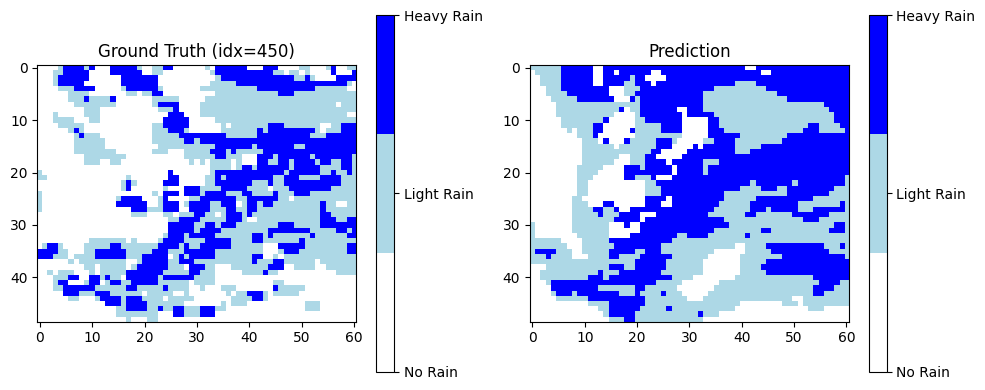

In [ ]:
plot_predictions_loader(model, test_loader, device, num_samples=5)

#### We can clearly see the ConvLSTM model outperforms the CNN and LSTM models with superior per-class accuracies and F1 scores.

#### Now we try to improve upon the model with increasing complexity and maybe tweak the loss fxn

### ConvLSTM Exp 2: Hybrid Loss: Weighted Cross Entropy + Dice Loss

We observed that the model performs well on No Rain, but struggles with:

* Light Rain (low F1)
* Heavy Rain (high recall but low precision → many false positives)

This is a typical issue in class-imbalanced segmentation/forecasting tasks.

Problem with using only Cross Entropy
* Even with class weights, Cross Entropy is still pixel-wise
* It does not directly optimize spatial overlap
* Leads to:
    * fragmented predictions
    * poor boundary learning
    * bias toward dominant classes

Dice Loss measures overlap between prediction and ground truth, making it:

* Sensitive to minority classes
* Better at capturing spatial structure
* Helpful for improving F1-score

Hence we use hybrid loss:

$$
\text{Loss} = (1 - \alpha)\, \cdot \text{Weighted Cross Entropy} + \alpha \cdot \text{Dice Loss}
$$


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvLSTMSeq2Seq(
    input_dim=8,
    num_classes=3,
    hidden_dim=32,
    rain_channel_idx=7
).to(device)

print(model)  # sanity check


ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(40, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(35, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (output_conv): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [ ]:
import numpy as np
import torch

def compute_class_weights_from_X(X_norm, tp_idx, look_back=16, num_classes=3, max_samples=1000):
    counts = np.zeros(num_classes, dtype=np.float64)

    T = X_norm.shape[0]

    N = T - look_back  # number of samples

    for i in range(N):
        t = i + look_back   # target timestep

        y = X_norm[t, tp_idx]   # (H, W)

        unique, freq = np.unique(y.astype(int), return_counts=True)

        for u, f in zip(unique, freq):
            if 0 <= u < num_classes:
                counts[u] += f

        if max_samples and i >= max_samples:
            break

    counts = np.maximum(counts, 1)

    # same logic as before
    weights = 1.0 / np.sqrt(counts)

    # normalize
    weights = weights / weights.sum() * num_classes

    return torch.tensor(weights, dtype=torch.float32)

tp_idx = 7

#Computing class weights
class_weights = compute_class_weights_from_X(
    X_norm,
    tp_idx=tp_idx,
    look_back=16,
    num_classes=3,
    max_samples=1000
).to(device)

import torch.nn.functional as F

import torch.nn as nn
import torch.nn.functional as F

class DiceLossIgnoreBG(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        targets_onehot = F.one_hot(targets, num_classes=self.num_classes)
        targets_onehot = targets_onehot.permute(0, 3, 1, 2).float()

        # Ignoring background (class 0) as it dominates the dataset
        probs = probs[:, 1:]              # (B, C-1, H, W)
        targets_onehot = targets_onehot[:, 1:]

        intersection = (probs * targets_onehot).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets_onehot.sum(dim=(2,3))

        dice = (2 * intersection + 1e-6) / (union + 1e-6)

        return 1 - dice.mean()

#### Alpha = 0.3

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

dice_loss = DiceLossIgnoreBG(num_classes=3)

class HybridLoss(nn.Module):
    def __init__(self, ce_loss, dice_loss, alpha=0.3):
        super().__init__()
        self.ce = ce_loss
        self.dice = dice_loss
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        dice = self.dice(logits, targets)
        return (1 - self.alpha) * ce + self.alpha * dice

# alpha is a new Hyperparameter
alpha = 0.3
criterion_hybrid = HybridLoss(criterion, dice_loss, alpha=alpha)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion_hybrid(outputs, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
import copy

EPOCHS = 100
PATIENCE = 4

best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()

        outputs = model(X_batch, target_len=1)
        outputs = outputs[:, 0]

        loss = criterion_hybrid(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion_hybrid(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("Validation improved — model saved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# ===== LOAD BEST MODEL =====
model.load_state_dict(best_model_wts)
print("✅ Best model loaded")


Epoch 1/100
Train Loss: 0.7337 | Val Loss: 0.7226
Validation improved — model saved

Epoch 2/100
Train Loss: 0.6650 | Val Loss: 0.6807
Validation improved — model saved

Epoch 3/100
Train Loss: 0.6397 | Val Loss: 0.6628
Validation improved — model saved

Epoch 4/100
Train Loss: 0.6283 | Val Loss: 0.6580
Validation improved — model saved

Epoch 5/100
Train Loss: 0.6207 | Val Loss: 0.6506
Validation improved — model saved

Epoch 6/100
Train Loss: 0.6149 | Val Loss: 0.6436
Validation improved — model saved

Epoch 7/100
Train Loss: 0.6106 | Val Loss: 0.6392
Validation improved — model saved

Epoch 8/100
Train Loss: 0.6079 | Val Loss: 0.6393
No improvement (1/4)

Epoch 9/100
Train Loss: 0.6044 | Val Loss: 0.6364
Validation improved — model saved

Epoch 10/100
Train Loss: 0.6017 | Val Loss: 0.6397
No improvement (1/4)

Epoch 11/100
Train Loss: 0.5998 | Val Loss: 0.6311
Validation improved — model saved

Epoch 12/100
Train Loss: 0.5978 | Val Loss: 0.6336
No improvement (1/4)

Epoch 13/100
Tr

In [ ]:
model.load_state_dict(best_model_wts)

xb, _ = next(iter(train_loader))
input_dim = xb.shape[2]

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": 32,      # match your model
    "num_classes": 3       # correct
}, "convlstm_m2_hybridloss_3.pth")

print("Full model checkpoint saved ✔")

Full model checkpoint saved ✔


In [ ]:
def predict(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]   # safer

            pred = torch.argmax(outputs, dim=1)

            preds.append(pred.cpu())
            targets.append(y_batch)

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return preds, targets


def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return (correct / total).item()


def class_wise_accuracy(preds, targets, num_classes=3):
    preds = preds.view(-1)
    targets = targets.view(-1)

    for cls in range(num_classes):
        mask = (targets == cls)

        if mask.sum() == 0:
            print(f"Class {cls}: No samples")
            continue

        acc = (preds[mask] == cls).float().mean()
        print(f"Class {cls} Accuracy: {acc:.4f}")


# ===== RUN =====
preds, targets = predict(model, test_loader)

acc = pixel_accuracy(preds, targets)
print(f"\nTest Pixel Accuracy: {acc:.4f}\n")

class_wise_accuracy(preds, targets, num_classes=3)


Test Pixel Accuracy: 0.7808

Class 0 Accuracy: 0.8205
Class 1 Accuracy: 0.5743
Class 2 Accuracy: 0.7293


In [ ]:
from sklearn.metrics import classification_report

# flatten
preds_flat = preds.view(-1).numpy()
targets_flat = targets.view(-1).numpy()

report = classification_report(
    targets_flat,
    preds_flat,
    labels=[0, 1, 2],
    target_names=["No Rain", "Light Rain", "Heavy Rain"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

     No Rain     0.9456    0.8205    0.8787   3126411
  Light Rain     0.4521    0.5743    0.5059    537482
  Heavy Rain     0.3573    0.7293    0.4796    257675

    accuracy                         0.7808   3921568
   macro avg     0.5850    0.7081    0.6214   3921568
weighted avg     0.8393    0.7808    0.8014   3921568



#### Alpha = 0.5

In [ ]:
import torch, gc

# delete big objects from previous run
del model
del optimizer

# if you stored preds / large tensors
# del preds, targets, outputs  # uncomment if they exist

gc.collect()
torch.cuda.empty_cache()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvLSTMSeq2Seq(
    input_dim=8,
    num_classes=3,
    hidden_dim=32,
    rain_channel_idx=7
).to(device)

print(model)  # sanity check

ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(40, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(35, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (output_conv): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [ ]:
alpha = 0.5
criterion_hybrid = HybridLoss(criterion, dice_loss, alpha=alpha)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
import copy

EPOCHS = 50
PATIENCE = 4

best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()

        outputs = model(X_batch, target_len=1)
        outputs = outputs[:, 0]

        loss = criterion_hybrid(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion_hybrid(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("Validation improved — model saved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# ===== LOAD BEST MODEL =====
model.load_state_dict(best_model_wts)
print("✅ Best model loaded")


Epoch 1/50
Train Loss: 0.7380 | Val Loss: 0.7308
Validation improved — model saved

Epoch 2/50
Train Loss: 0.6811 | Val Loss: 0.6920
Validation improved — model saved

Epoch 3/50
Train Loss: 0.6575 | Val Loss: 0.6779
Validation improved — model saved

Epoch 4/50
Train Loss: 0.6454 | Val Loss: 0.6652
Validation improved — model saved

Epoch 5/50
Train Loss: 0.6376 | Val Loss: 0.6586
Validation improved — model saved

Epoch 6/50
Train Loss: 0.6326 | Val Loss: 0.6547
Validation improved — model saved

Epoch 7/50
Train Loss: 0.6280 | Val Loss: 0.6503
Validation improved — model saved

Epoch 8/50
Train Loss: 0.6245 | Val Loss: 0.6466
Validation improved — model saved

Epoch 9/50
Train Loss: 0.6219 | Val Loss: 0.6453
Validation improved — model saved

Epoch 10/50
Train Loss: 0.6193 | Val Loss: 0.6445
Validation improved — model saved

Epoch 11/50
Train Loss: 0.6170 | Val Loss: 0.6416
Validation improved — model saved

Epoch 12/50
Train Loss: 0.6151 | Val Loss: 0.6425
No improvement (1/4)

E

In [ ]:
model.load_state_dict(best_model_wts)

xb, _ = next(iter(train_loader))
input_dim = xb.shape[2]

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": 32,      # match your model
    "num_classes": 3       # correct
}, "convlstm_m2_hybridloss_5.pth")

print("Full model checkpoint saved ✔")

Full model checkpoint saved ✔


In [ ]:
def predict(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]   # safer

            pred = torch.argmax(outputs, dim=1)

            preds.append(pred.cpu())
            targets.append(y_batch)

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return preds, targets


def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return (correct / total).item()


def class_wise_accuracy(preds, targets, num_classes=3):
    preds = preds.view(-1)
    targets = targets.view(-1)

    for cls in range(num_classes):
        mask = (targets == cls)

        if mask.sum() == 0:
            print(f"Class {cls}: No samples")
            continue

        acc = (preds[mask] == cls).float().mean()
        print(f"Class {cls} Accuracy: {acc:.4f}")

preds, targets = predict(model, test_loader)

acc = pixel_accuracy(preds, targets)
print(f"\nTest Pixel Accuracy: {acc:.4f}\n")

class_wise_accuracy(preds, targets, num_classes=3)


Test Pixel Accuracy: 0.7796

Class 0 Accuracy: 0.8178
Class 1 Accuracy: 0.5971
Class 2 Accuracy: 0.6973


In [ ]:
from sklearn.metrics import classification_report

# flatten
preds_flat = preds.view(-1).numpy()
targets_flat = targets.view(-1).numpy()

report = classification_report(
    targets_flat,
    preds_flat,
    labels=[0, 1, 2],
    target_names=["No Rain", "Light Rain", "Heavy Rain"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

     No Rain     0.9457    0.8178    0.8771   3126411
  Light Rain     0.4472    0.5971    0.5114    537482
  Heavy Rain     0.3591    0.6973    0.4741    257675

    accuracy                         0.7796   3921568
   macro avg     0.5840    0.7040    0.6209   3921568
weighted avg     0.8388    0.7796    0.8005   3921568



#### Alpha = 0.65

In [ ]:
import torch, gc

# delete big objects from previous run
del model
del optimizer

# if you stored preds / large tensors
# del preds, targets, outputs  # uncomment if they exist

gc.collect()
torch.cuda.empty_cache()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvLSTMSeq2Seq(
    input_dim=8,
    num_classes=3,
    hidden_dim=32,
    rain_channel_idx=7
).to(device)

print(model)  # sanity check

ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(40, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(35, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (output_conv): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [ ]:
alpha = 0.65
criterion_hybrid = HybridLoss(criterion, dice_loss, alpha=alpha)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
import copy

EPOCHS = 50
PATIENCE = 4

best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()

        outputs = model(X_batch, target_len=1)
        outputs = outputs[:, 0]

        loss = criterion_hybrid(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion_hybrid(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("Validation improved — model saved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# ===== LOAD BEST MODEL =====
model.load_state_dict(best_model_wts)
print("✅ Best model loaded")


Epoch 1/50
Train Loss: 0.7398 | Val Loss: 0.7197
Validation improved — model saved

Epoch 2/50
Train Loss: 0.6842 | Val Loss: 0.6964
Validation improved — model saved

Epoch 3/50
Train Loss: 0.6620 | Val Loss: 0.6713
Validation improved — model saved

Epoch 4/50
Train Loss: 0.6505 | Val Loss: 0.6696
Validation improved — model saved

Epoch 5/50
Train Loss: 0.6437 | Val Loss: 0.6609
Validation improved — model saved

Epoch 6/50
Train Loss: 0.6386 | Val Loss: 0.6564
Validation improved — model saved

Epoch 7/50
Train Loss: 0.6350 | Val Loss: 0.6518
Validation improved — model saved

Epoch 8/50
Train Loss: 0.6311 | Val Loss: 0.6507
Validation improved — model saved

Epoch 9/50
Train Loss: 0.6285 | Val Loss: 0.6499
Validation improved — model saved

Epoch 10/50
Train Loss: 0.6263 | Val Loss: 0.6467
Validation improved — model saved

Epoch 11/50
Train Loss: 0.6241 | Val Loss: 0.6453
Validation improved — model saved

Epoch 12/50
Train Loss: 0.6225 | Val Loss: 0.6420
Validation improved — m

In [ ]:
model.load_state_dict(best_model_wts)

xb, _ = next(iter(train_loader))
input_dim = xb.shape[2]

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": 32,      # match your model
    "num_classes": 3       # correct
}, "convlstm_m2_hybridloss_65.pth")

print("Full model checkpoint saved ✔")

Full model checkpoint saved ✔


In [ ]:
preds, targets = predict(model, test_loader)

acc = pixel_accuracy(preds, targets)
print(f"\nTest Pixel Accuracy: {acc:.4f}\n")

class_wise_accuracy(preds, targets, num_classes=3)


Test Pixel Accuracy: 0.7764

Class 0 Accuracy: 0.8133
Class 1 Accuracy: 0.6039
Class 2 Accuracy: 0.6895


In [ ]:
from sklearn.metrics import classification_report

# flatten
preds_flat = preds.view(-1).numpy()
targets_flat = targets.view(-1).numpy()

report = classification_report(
    targets_flat,
    preds_flat,
    labels=[0, 1, 2],
    target_names=["No Rain", "Light Rain", "Heavy Rain"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

     No Rain     0.9459    0.8133    0.8746   3126411
  Light Rain     0.4360    0.6039    0.5064    537482
  Heavy Rain     0.3633    0.6895    0.4759    257675

    accuracy                         0.7764   3921568
   macro avg     0.5817    0.7022    0.6190   3921568
weighted avg     0.8377    0.7764    0.7979   3921568



### Hybrid Loss (Dice + Weighted CE) — Alpha Sweep Results

We evaluated different values of ( \alpha ) in the hybrid loss:

$$
\text{Loss} = (1 - \alpha)\cdot\mathcal{L}{CE} + \alpha⋅\mathcal{L}{Dice}
$$

Early stopping (patience = 4) was used, so epochs vary slightly.


#### Results Summary
* **(alpha = 0.3)**
  * Accuracy: 0.7808
  * Class Accuracies:
    * No Rain: 0.8205
    * Light Rain: 0.5743
    * Heavy Rain: 0.7293

* Classification Report:

    * No Rain     → Precision: 0.9456 | Recall: 0.8205 | F1: 0.8787
    * Light Rain  → Precision: 0.4521 | Recall: 0.5743 | F1: 0.5059
    * Heavy Rain  → Precision: 0.3573 | Recall: 0.7293 | F1: 0.4796
    * Macro Avg F1: 0.6214  ← BEST



---


* **(alpha = 0.5)**
  * Accuracy: 0.7796
  * Class Accuracies:
    * No Rain: 0.8178
    * Light Rain: 0.5971
    * Heavy Rain: 0.6973

* Classification Report:

    * No Rain     → Precision: 0.9457 | Recall: 0.8178 | F1: 0.8771
    * Light Rain  → Precision: 0.4472 | Recall: 0.5971 | F1: 0.5114
    * Heavy Rain  → Precision: 0.3591 | Recall: 0.6973 | F1: 0.4741
    * Macro Avg F1: 0.6209


---

* **(alpha = 0.65)**
  * Accuracy:  0.7764
  * Class Accuracies:
    * No Rain: 0.8133
    * Light Rain: 0.6039
    * Heavy Rain: 0.6895

* Classification Report:

    * No Rain     → Precision: 0.9459 | Recall: 0.8133 | F1: 0.8746
    * Light Rain  → Precision: 0.4360 | Recall: 0.6039 | F1: 0.5064
    * Heavy Rain  → Precision: 0.3633 | Recall: 0.6895 | F1: 0.4759
    * Macro Avg F1: 0.6190


### Observations

- Increasing $\alpha$:
  - ↑ Focus on rain regions  
  - ↑ Light Rain recall  
  - ↓ Heavy Rain recall  
  - ↓ Overall accuracy  

- Heavy Rain shows a **precision–recall tradeoff**:
  - Higher $\alpha$ → precision ↑, recall ↓ slightly  
  - Best balance at lower $\alpha$  

---

### Final Conclusion

- **Best overall performance:** $\alpha = 0.3$  
- Highest **macro F1-score**  
- Best balance across all classes  
- More stable predictions  

---

### Key Insight

> Hybrid loss allows explicit control over the **precision–recall tradeoff**  
> via $\alpha$, but excessive weighting toward Dice can degrade overall structure.




In [ ]:
import torch
import torch.nn as nn

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=padding
        )

        #  Peephole parameters
        self.Wci = nn.Parameter(torch.zeros(1, hidden_dim, 1, 1))
        self.Wcf = nn.Parameter(torch.zeros(1, hidden_dim, 1, 1))
        self.Wco = nn.Parameter(torch.zeros(1, hidden_dim, 1, 1))

        self.hidden_dim = hidden_dim

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)

        conv_out = self.conv(combined)
        i, f, o, g = torch.chunk(conv_out, 4, dim=1)

        # Add peephole connections
        i = torch.sigmoid(i + self.Wci * c)
        f = torch.sigmoid(f + self.Wcf * c)

        g = torch.tanh(g)

        c_next = f * c + i * g

        o = torch.sigmoid(o + self.Wco * c_next)

        h_next = o * torch.tanh(c_next)

        return h_next, c_next

In [ ]:
from typing import Tuple
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()

        self.cell1 = ConvLSTMCell(input_dim, 32)
        self.cell2 = ConvLSTMCell(32, 64)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, T, C, H, W = x.shape

        h1 = torch.zeros(B, 32, H, W, device=x.device)
        c1 = torch.zeros_like(h1)

        h2 = torch.zeros(B, 64, H, W, device=x.device)
        c2 = torch.zeros_like(h2)

        for t in range(T):
            x_t = x[:, t]

            h1, c1 = self.cell1(x_t, h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)

        return h2, c2

In [ ]:
class Decoder(nn.Module):
    def __init__(self, hidden_dim: int, output_dim: int):
        super().__init__()

        self.convlstm = ConvLSTMCell(output_dim, hidden_dim)

        # 🔥 upgraded refinement head
        self.output_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim // 2, output_dim, kernel_size=1)
        )

    def forward(self, h, c, x_init, target_len):
        B, _, H, W = h.shape
        outputs = []

        x = x_init

        for _ in range(target_len):
            h, c = self.convlstm(x, h, c)
            x = self.output_conv(h)
            outputs.append(x)

        return torch.stack(outputs, dim=1)

In [ ]:
'''class Decoder(nn.Module):
    def __init__(self, hidden_dim: int, output_dim: int):
        super().__init__()
        self.convlstm = ConvLSTMCell(output_dim, hidden_dim)
        self.output_conv = nn.Conv2d(hidden_dim, output_dim, kernel_size=1)

    def forward(self, h, c, x_init, target_len):
        B, _, H, W = h.shape
        outputs = []

        x = x_init

        for _ in range(target_len):
            h, c = self.convlstm(x, h, c)
            x = self.output_conv(h)
            outputs.append(x)

        return torch.stack(outputs, dim=1)'''

'class Decoder(nn.Module):\n    def __init__(self, hidden_dim: int, output_dim: int):\n        super().__init__()\n        self.convlstm = ConvLSTMCell(output_dim, hidden_dim)\n        self.output_conv = nn.Conv2d(hidden_dim, output_dim, kernel_size=1)\n\n    def forward(self, h, c, x_init, target_len):\n        B, _, H, W = h.shape\n        outputs = []\n\n        x = x_init\n\n        for _ in range(target_len):\n            h, c = self.convlstm(x, h, c)\n            x = self.output_conv(h)\n            outputs.append(x)\n\n        return torch.stack(outputs, dim=1)'

In [ ]:
import torch.nn.functional as F

class ConvLSTMSeq2Seq(nn.Module):
    def __init__(self, input_dim, num_classes, rain_channel_idx=7):
        super().__init__()

        self.encoder = Encoder(input_dim)
        self.decoder = Decoder(hidden_dim=64, output_dim=num_classes)

        self.rain_channel_idx = rain_channel_idx
        self.num_classes = num_classes

    def forward(self, x, target_len=1):
        h, c = self.encoder(x)

        # last timestep rain
        x_init = x[:, -1, self.rain_channel_idx]

        # one-hot
        x_init = F.one_hot(
            x_init.long(), num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        out = self.decoder(h, c, x_init, target_len)
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvLSTMSeq2Seq(
    input_dim=8,
    num_classes=3,
    rain_channel_idx=7
).to(device)

print(model)  # sanity check


ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (cell1): ConvLSTMCell(
      (conv): Conv2d(40, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (cell2): ConvLSTMCell(
      (conv): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(67, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (output_conv): Sequential(
      (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)


In [ ]:
import numpy as np
import torch

def compute_class_weights_from_X(X_norm, tp_idx, look_back=16, num_classes=3, max_samples=1000):
    counts = np.zeros(num_classes, dtype=np.float64)

    T = X_norm.shape[0]

    N = T - look_back  # number of samples

    for i in range(N):
        t = i + look_back   # target timestep

        y = X_norm[t, tp_idx]   # (H, W)

        unique, freq = np.unique(y.astype(int), return_counts=True)

        for u, f in zip(unique, freq):
            if 0 <= u < num_classes:
                counts[u] += f

        if max_samples and i >= max_samples:
            break

    counts = np.maximum(counts, 1)

    # same logic as before
    weights = 1.0 / np.sqrt(counts)

    # normalize
    weights = weights / weights.sum() * num_classes

    return torch.tensor(weights, dtype=torch.float32)

tp_idx = 7

#Computing class weights
class_weights = compute_class_weights_from_X(
    X_norm,
    tp_idx=tp_idx,
    look_back=16,
    num_classes=3,
    max_samples=1000
).to(device)

import torch.nn.functional as F

import torch.nn as nn
import torch.nn.functional as F

class DiceLossIgnoreBG(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        targets_onehot = F.one_hot(targets, num_classes=self.num_classes)
        targets_onehot = targets_onehot.permute(0, 3, 1, 2).float()

        # Ignoring background (class 0) as it dominates the dataset
        probs = probs[:, 1:]              # (B, C-1, H, W)
        targets_onehot = targets_onehot[:, 1:]

        intersection = (probs * targets_onehot).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets_onehot.sum(dim=(2,3))

        dice = (2 * intersection + 1e-6) / (union + 1e-6)

        return 1 - dice.mean()

NameError: name 'X_norm' is not defined

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

dice_loss = DiceLossIgnoreBG(num_classes=3)

class HybridLoss(nn.Module):
    def __init__(self, ce_loss, dice_loss, alpha=0.3):
        super().__init__()
        self.ce = ce_loss
        self.dice = dice_loss
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        dice = self.dice(logits, targets)
        return (1 - self.alpha) * ce + self.alpha * dice

# alpha is a new Hyperparameter
alpha = 0.55
criterion_hybrid = HybridLoss(criterion, dice_loss, alpha=alpha)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion_hybrid(outputs, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
import copy

EPOCHS = 24
PATIENCE = 10

best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()

        outputs = model(X_batch, target_len=1)
        outputs = outputs[:, 0]

        loss = criterion_hybrid(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            loss = criterion_hybrid(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("Validation improved — model saved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

# ===== LOAD BEST MODEL =====
model.load_state_dict(best_model_wts)
print("✅ Best model loaded")


Epoch 1/24
Train Loss: 0.6325 | Val Loss: 0.6510
Validation improved — model saved

Epoch 2/24
Train Loss: 0.6230 | Val Loss: 0.6417
Validation improved — model saved

Epoch 3/24
Train Loss: 0.6167 | Val Loss: 0.6379
Validation improved — model saved

Epoch 4/24
Train Loss: 0.6102 | Val Loss: 0.6326
Validation improved — model saved

Epoch 5/24
Train Loss: 0.6062 | Val Loss: 0.6302
Validation improved — model saved

Epoch 6/24
Train Loss: 0.6017 | Val Loss: 0.6291
Validation improved — model saved

Epoch 7/24
Train Loss: 0.5982 | Val Loss: 0.6253
Validation improved — model saved

Epoch 8/24
Train Loss: 0.5942 | Val Loss: 0.6247
Validation improved — model saved

Epoch 9/24
Train Loss: 0.5909 | Val Loss: 0.6255
No improvement (1/10)

Epoch 10/24
Train Loss: 0.5882 | Val Loss: 0.6181
Validation improved — model saved

Epoch 11/24
Train Loss: 0.5858 | Val Loss: 0.6166
Validation improved — model saved

Epoch 12/24
Train Loss: 0.5831 | Val Loss: 0.6191
No improvement (1/10)

Epoch 13/24


In [ ]:
model.load_state_dict(best_model_wts)

xb, _ = next(iter(train_loader))
input_dim = xb.shape[2]

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": 32,      # match your model
    "num_classes": 3       # correct
}, "convlstm_m3_hybridloss_55.pth")

print("Full model checkpoint saved ✔")

Full model checkpoint saved ✔


In [ ]:
import torch

# Load checkpoint
checkpoint = torch.load(
    "convlstm_m3_hybridloss_55.pth",
    map_location="cpu"
)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])

# Set to eval mode
model.eval()

ConvLSTMSeq2Seq(
  (encoder): Encoder(
    (cell1): ConvLSTMCell(
      (conv): Conv2d(40, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (cell2): ConvLSTMCell(
      (conv): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (convlstm): ConvLSTMCell(
      (conv): Conv2d(67, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (output_conv): Sequential(
      (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)

In [ ]:
def predict(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]   # safer

            pred = torch.argmax(outputs, dim=1)

            preds.append(pred.cpu())
            targets.append(y_batch)

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return preds, targets


def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return (correct / total).item()


def class_wise_accuracy(preds, targets, num_classes=3):
    preds = preds.view(-1)
    targets = targets.view(-1)

    for cls in range(num_classes):
        mask = (targets == cls)

        if mask.sum() == 0:
            print(f"Class {cls}: No samples")
            continue

        acc = (preds[mask] == cls).float().mean()
        print(f"Class {cls} Accuracy: {acc:.4f}")


# ===== RUN =====
preds, targets = predict(model, test_loader)

acc = pixel_accuracy(preds, targets)
print(f"\nTest Pixel Accuracy: {acc:.4f}\n")

class_wise_accuracy(preds, targets, num_classes=3)


Test Pixel Accuracy: 0.7914

Class 0 Accuracy: 0.8298
Class 1 Accuracy: 0.6129
Class 2 Accuracy: 0.6980


In [ ]:
from sklearn.metrics import classification_report

# flatten
preds_flat = preds.view(-1).numpy()
targets_flat = targets.view(-1).numpy()

report = classification_report(
    targets_flat,
    preds_flat,
    labels=[0, 1, 2],
    target_names=["No Rain", "Light Rain", "Heavy Rain"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

     No Rain     0.9480    0.8298    0.8849   3126411
  Light Rain     0.4580    0.6129    0.5243    537482
  Heavy Rain     0.3862    0.6980    0.4972    257675

    accuracy                         0.7914   3921568
   macro avg     0.5974    0.7136    0.6355   3921568
weighted avg     0.8439    0.7914    0.8100   3921568



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap

def plot_predictions_loader(model, loader, device, num_samples=5):
    model.eval()

    # ===== Colormap (adapted to 3 classes) =====
    cmap = ListedColormap(['white', 'lightblue', 'blue'])
    class_names = ['No Rain', 'Light Rain', 'Heavy Rain']

    all_preds = []
    all_targets = []

    # ===== Collect predictions =====
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch, target_len=1)
            outputs = outputs[:, 0]

            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    print("Predictions shape:", all_preds.shape)
    print("Targets shape:", all_targets.shape)

    # ===== Plot random samples =====
    total = all_targets.shape[0]
    indices = np.random.choice(total, num_samples, replace=False)

    for i in indices:
        plt.figure(figsize=(10, 4))

        # Ground truth
        plt.subplot(1, 2, 1)
        plt.imshow(all_targets[i], cmap=cmap, vmin=0, vmax=2)
        plt.title(f"Ground Truth (idx={i})")
        cbar = plt.colorbar(ticks=[0, 1, 2])
        cbar.ax.set_yticklabels(class_names)

        # Prediction
        plt.subplot(1, 2, 2)
        plt.imshow(all_preds[i], cmap=cmap, vmin=0, vmax=2)
        plt.title("Prediction")
        cbar = plt.colorbar(ticks=[0, 1, 2])
        cbar.ax.set_yticklabels(class_names)

        plt.tight_layout()
        plt.show()

Predictions shape: torch.Size([1312, 49, 61])
Targets shape: torch.Size([1312, 49, 61])


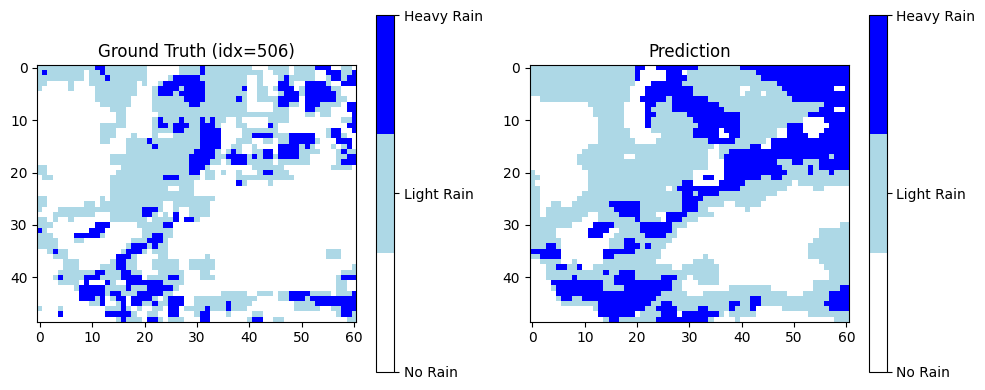

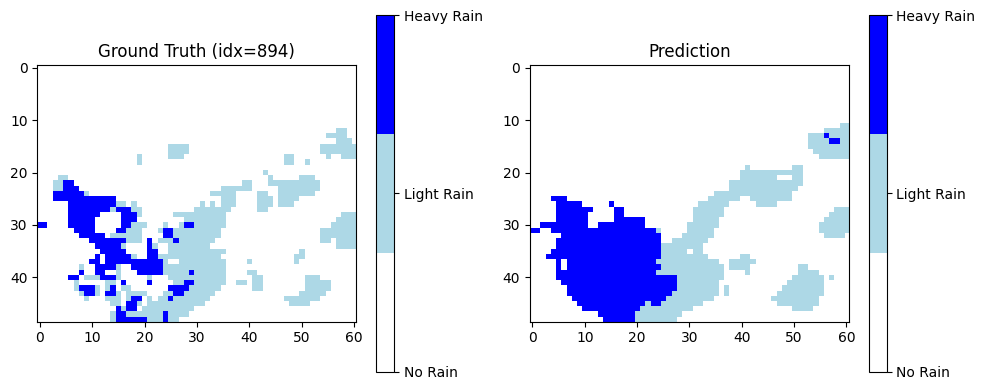

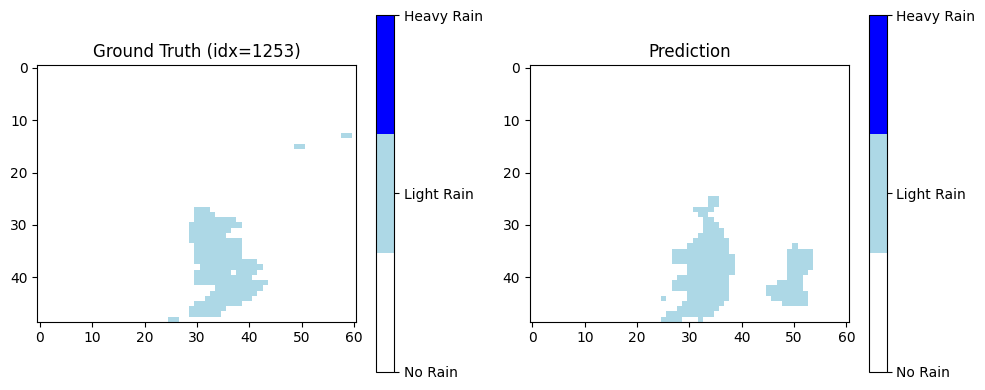

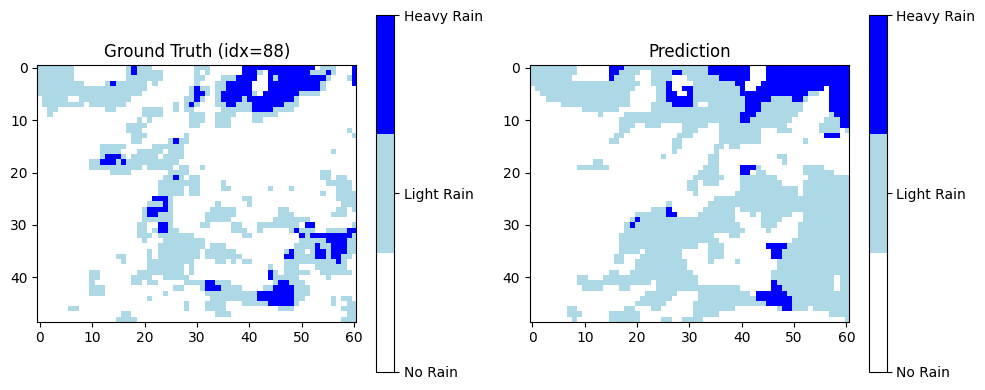

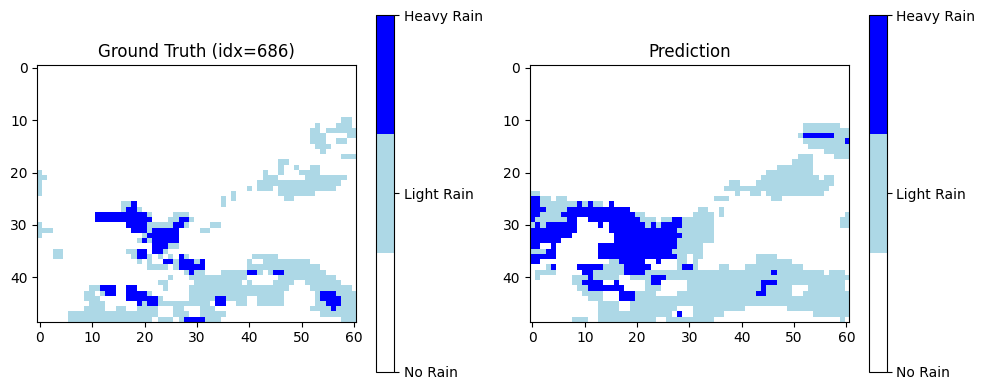

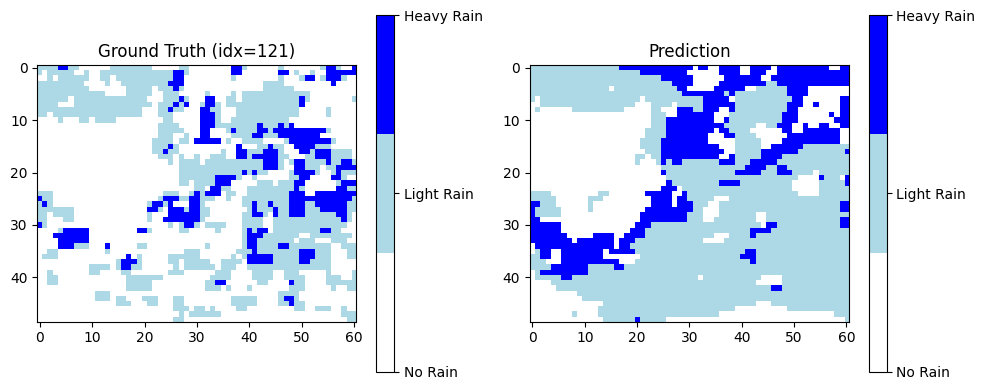

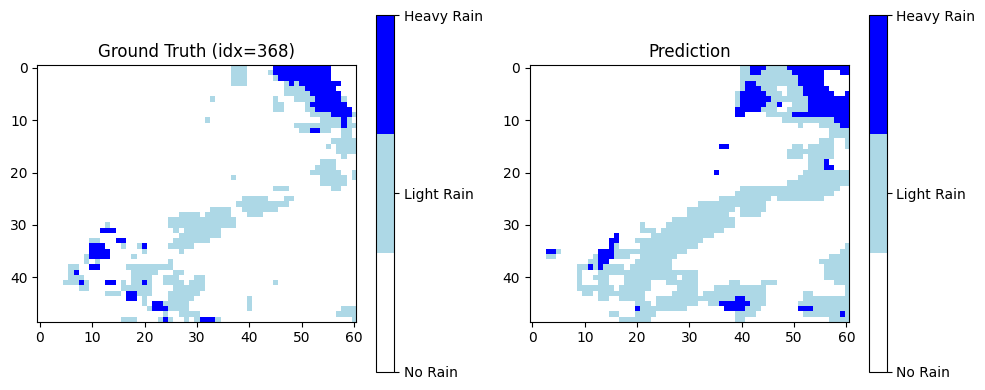

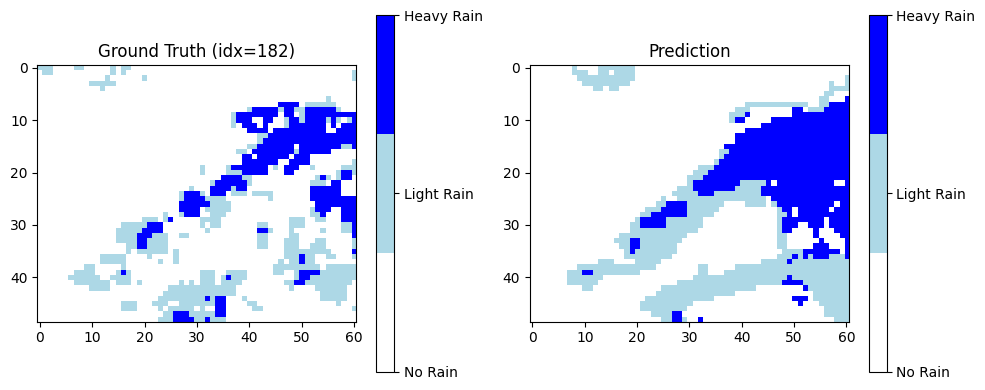

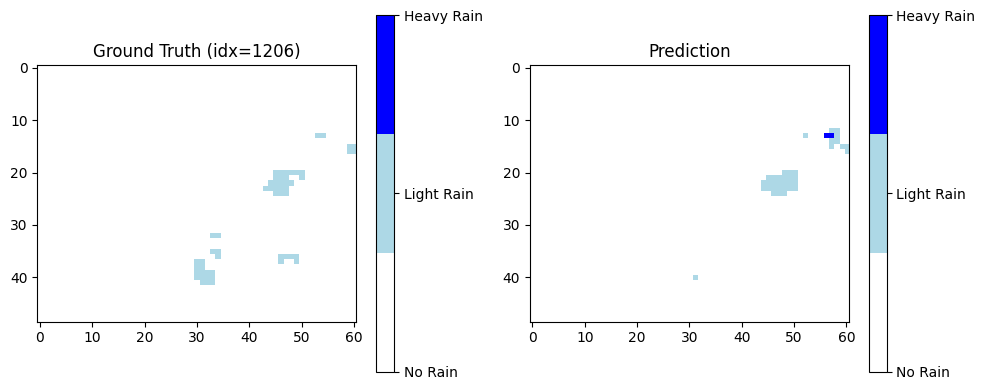

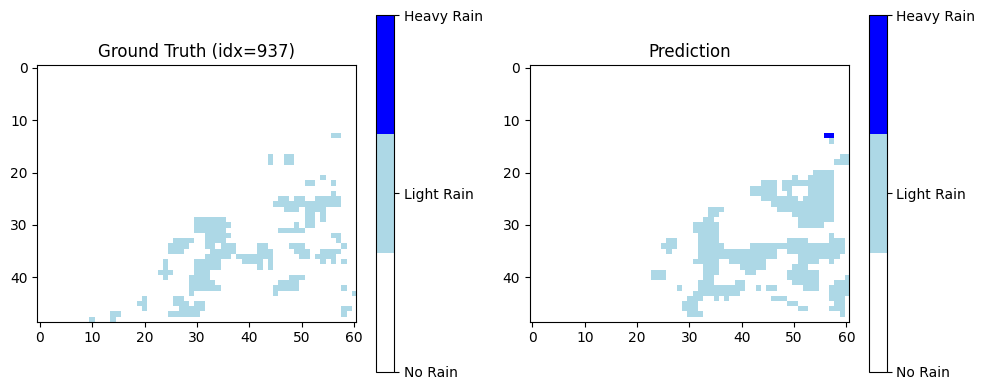

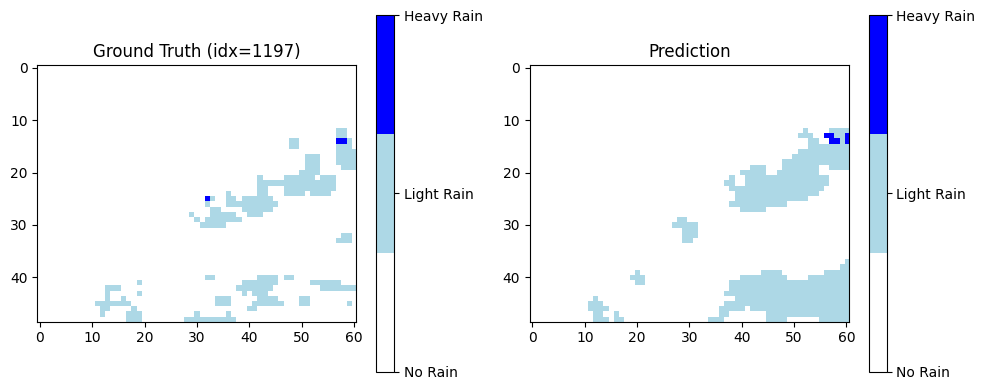

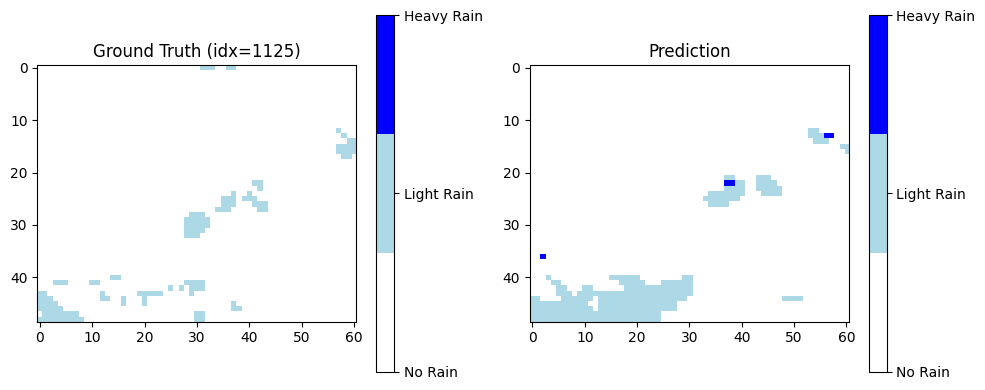

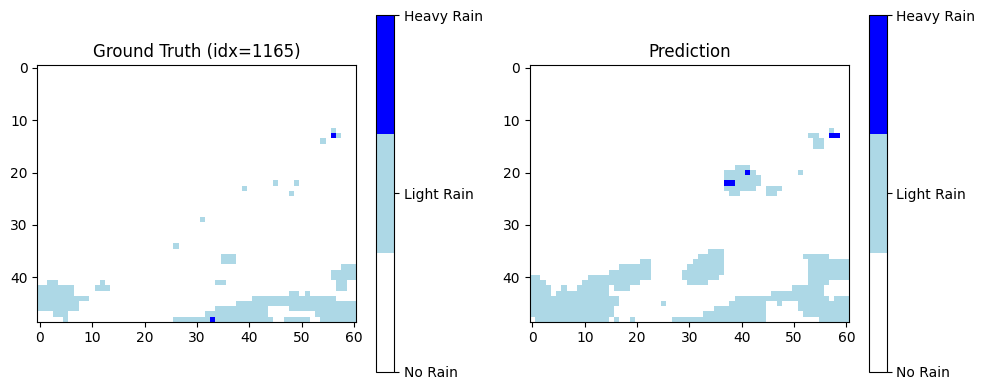

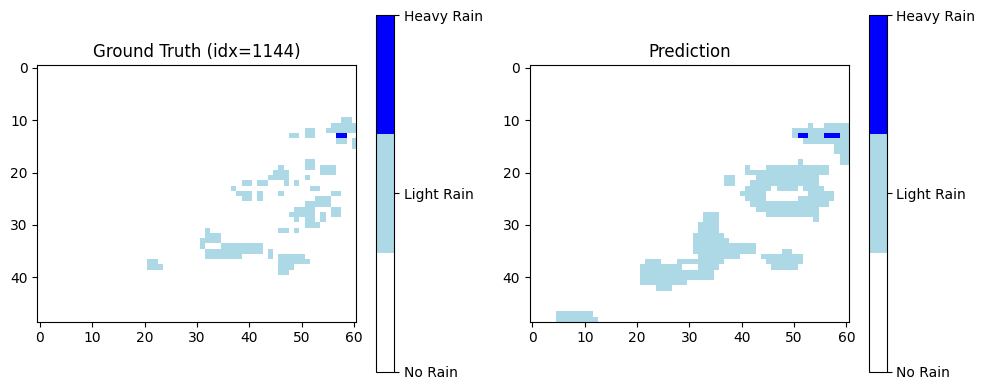

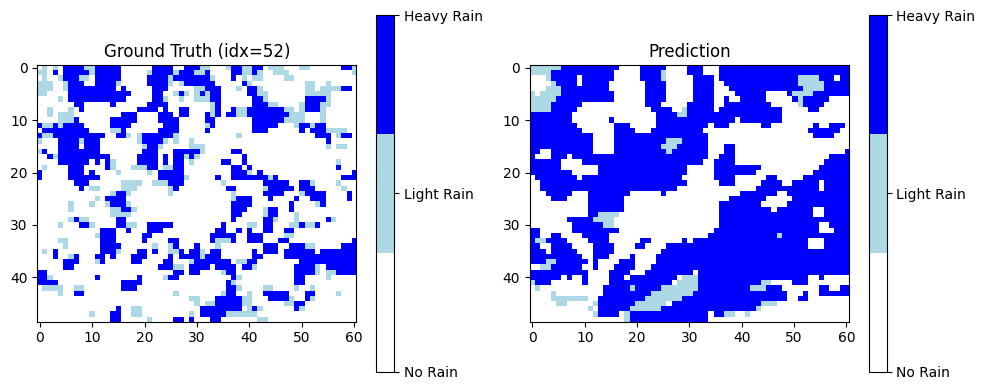

In [ ]:
plot_predictions_loader(model, test_loader, device, num_samples=15)